# Sepsis-RL SOFA Leakage Audit — Empirical Protocol (Experiments 1, 2, 3, 5; Exp. 4 optional)

This notebook implements, on an independent MIMIC-IV BigQuery extraction, the exact
pre-specified analysis plan from **Section 7** of *"When the State Contains the Action:
A Formal and Empirical Audit of Treatment Information in Sepsis Reinforcement Learning."*

It replaces the two prior drafts:
- `More_clear_5 (4).ipynb` — cohort/feature extraction for a different (PSR representation-learning)
  project, reused here for its working BigQuery patterns.
- `Untitled10 (1).ipynb` — correct analysis logic for Experiments 1/2/3/5, but never wired to real data
  (`vitals_df`, `vaso_bins_df`, `X_last`, `feature_names`, `y_action`, `stay_ids` were never built).

**What this notebook adds that neither draft had:**
1. A defensible **Sepsis-3 cohort** (not just "any vasopressor use").
2. **Per-drug vasopressor dose rates** (dopamine, dobutamine, epinephrine, norepinephrine) at
   4-hour decision resolution — required for Experiment 1's MAP-vs-dose decomposition.
3. **Two temporal aggregations of every SOFA-relevant feature**: the clinical-convention 24h
   worst-value window, and a 4h decision-aligned window (a Tang-et-al.–style correction) — required
   for Experiment 3.
4. **State variants A–E** built at the patient-*timestep* level (not just "last timestep"), matching
   the manuscript's "for every eligible patient-timestep" framing in Experiment 1/2.
5. Multi-probe (logreg / RF / gradient boosting) action-recoverability, calibration, and a mutual-information
   dependence measure, per the manuscript's Experiment 2 spec.
6. A **negative-control battery** matching Experiment 5's full list (shuffled labels, temporally
   shifted actions, physiology-only placebo features matched on prevalence) — not just shuffled labels.
7. Auto-generated **Table 3 / Figures 3–5** and a results-text block that can be pasted directly into
   Section 8 of the manuscript.

Run cells top to bottom in Google Colab. You need BigQuery access to `physionet-data` (MIMIC-IV) and
write access to a scratch dataset in your own GCP project.

**Before running:** set `PROJECT_ID` and `SCRATCH_DATASET` in the config cell below.


## 0. Setup, Configuration, Reproducibility

In [ ]:

!pip install --upgrade google-cloud-bigquery --quiet
from google.colab import auth
auth.authenticate_user()
print("Authenticated.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.3/264.3 kB 10.4 MB/s eta 0:00:00
Authenticated.


In [1]:

import os, json, math, random, warnings
from dataclasses import dataclass, asdict, field
from pathlib import Path

import numpy as np
import pandas as pd
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------------------
# >>> EDIT THESE TWO LINES FOR YOUR OWN GCP PROJECT <<<
PROJECT_ID = "commanding-pier-456419-p8"
SCRATCH_DATASET = f"{PROJECT_ID}.temp_dataset"
# ----------------------------------------------------------------------------

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DECISION_INTERVAL_HOURS = 4      # matches manuscript's "commonly 4 hours" decision cadence
SOFA_WINDOW_HOURS = 24            # matches manuscript's "commonly 24 hours" clinical convention
HORIZON_HOURS = 72                # first 72h of the ICU stay, i.e. 18 decision bins of 4h each
N_BINS = HORIZON_HOURS // DECISION_INTERVAL_HOURS

OUT_DIR = Path("results")
OUT_DIR.mkdir(exist_ok=True)

client = bigquery.Client(project=PROJECT_ID)

def run_query(sql, label=None):
    if label:
        print(f"Running: {label} ...")
    df = client.query(sql, location="US").to_dataframe()
    if label:
        print(f"  -> {df.shape[0]:,} rows, {df.shape[1]} cols")
    return df

print(f"Decision interval: {DECISION_INTERVAL_HOURS}h  |  SOFA window: {SOFA_WINDOW_HOURS}h  |  "
      f"Horizon: {HORIZON_HOURS}h  ->  {N_BINS} decision bins per stay")


Decision interval: 4h  |  SOFA window: 24h  |  Horizon: 72h  ->  18 decision bins per stay


## 1. Cohort Selection (Sepsis-3)

The manuscript's protocol requires patients who plausibly triggered a treatment decision, not simply
"anyone who ever received a vasopressor" (the cohort definition used in `More_clear_5`). We use the
standard, publicly available `mimiciv_derived.sepsis3` concept table (Johnson et al.-style Sepsis-3
labeling: suspicion of infection + SOFA increase >= 2), restricted to adults, first ICU stay, LOS >= 1
day, and vasopressor-treated (so Experiment 1's cardiovascular decomposition has a non-trivial
dose-exposed population). If your BigQuery grant does not include `mimiciv_derived`, a fallback
suspicion-of-infection query is provided (commented) — see the note in the except branch.


In [2]:

cohort_query = f'''
WITH ranked_icu AS (
  SELECT
    ie.subject_id, ie.hadm_id, ie.stay_id, ie.intime, ie.outtime, ie.los,
    ie.first_careunit, p.anchor_age, adm.deathtime, adm.hospital_expire_flag,
    ROW_NUMBER() OVER (PARTITION BY ie.subject_id ORDER BY ie.intime) AS rn
  FROM `physionet-data.mimiciv_3_1_icu.icustays` ie
  JOIN `physionet-data.mimiciv_3_1_hosp.patients` p USING(subject_id)
  JOIN `physionet-data.mimiciv_3_1_hosp.admissions` adm USING(hadm_id)
  WHERE ie.first_careunit NOT IN ('NICU', 'PICU')
    AND p.anchor_age >= 18
    AND ie.los >= 1.0
),
first_icu AS (SELECT * FROM ranked_icu WHERE rn = 1),
vasopressor_stays AS (
  SELECT DISTINCT stay_id
  FROM `physionet-data.mimiciv_3_1_icu.inputevents`
  WHERE itemid IN (221906, 221289, 222315, 221749, 221662)  -- norepi, epi, vaso, phenyl, dopa
    AND amount > 0
),
sepsis3_stays AS (
  SELECT DISTINCT stay_id
  FROM `physionet-data.mimiciv_3_1_derived.sepsis3`
  WHERE sepsis3 IS TRUE
)
SELECT f.*
FROM first_icu f
INNER JOIN vasopressor_stays v USING(stay_id)
INNER JOIN sepsis3_stays s USING(stay_id)
LIMIT 20000
'''

try:
    cohort_df = run_query(cohort_query, "Sepsis-3 vasopressor-treated cohort")
except NotFound:
    print("mimiciv_derived.sepsis3 not found in your BigQuery grant.")
    print("Falling back to a vasopressor-treated ICU cohort WITHOUT the Sepsis-3 infection/SOFA-delta")
    print("filter. This weakens the external validity of the cohort claim in Methods/Section 7 and")
    print("should be reported as a deviation from the pre-specified protocol if used.")
    fallback_query = cohort_query.split("sepsis3_stays AS")[0] + '''
SELECT f.*
FROM first_icu f
INNER JOIN vasopressor_stays v USING(stay_id)
LIMIT 20000
'''
    cohort_df = run_query(fallback_query, "Fallback vasopressor-treated cohort (no Sepsis-3 filter)")

stay_ids = cohort_df["stay_id"].unique()
print(f"\nFinal cohort: {len(stay_ids):,} ICU stays")

cohort_schema = [
    bigquery.SchemaField("subject_id", "INTEGER"),
    bigquery.SchemaField("hadm_id", "INTEGER"),
    bigquery.SchemaField("stay_id", "INTEGER"),
    bigquery.SchemaField("intime", "DATETIME"),
    bigquery.SchemaField("outtime", "DATETIME"),
    bigquery.SchemaField("los", "FLOAT"),
    bigquery.SchemaField("first_careunit", "STRING"),
    bigquery.SchemaField("anchor_age", "INTEGER"),
    bigquery.SchemaField("deathtime", "DATETIME"),
    bigquery.SchemaField("hospital_expire_flag", "INTEGER"),
    bigquery.SchemaField("rn", "INTEGER"),
]
job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE", schema=cohort_schema)
job = client.load_table_from_dataframe(cohort_df, f"{SCRATCH_DATASET}.sepsis_cohort", job_config=job_config)
job.result()
print("Cohort table saved to BigQuery scratch dataset.")


Running: Sepsis-3 vasopressor-treated cohort ...


  -> 11,354 rows, 11 cols

Final cohort: 11,354 ICU stays


Cohort table saved to BigQuery scratch dataset.


## 2. Extract Vitals and Labs (raw timestamps, both windowings computed later)

We keep raw `charttime` here rather than pre-binning, so the same extraction can support both the
24h clinical-convention window and the 4h decision-aligned window needed for Experiment 3.


In [3]:

vitals_query = f'''
WITH vital_items AS (
  SELECT * FROM UNNEST([
    STRUCT(220045 AS itemid, 'heart_rate' AS label),
    STRUCT(220179 AS itemid, 'sbp' AS label),
    STRUCT(220180 AS itemid, 'dbp' AS label),
    STRUCT(220181 AS itemid, 'mbp' AS label),          -- MAP
    STRUCT(220052 AS itemid, 'mbp_arterial' AS label),  -- invasive MAP, some ICUs chart this instead
    STRUCT(220210 AS itemid, 'resp_rate' AS label),
    STRUCT(220277 AS itemid, 'spo2' AS label),
    STRUCT(223761 AS itemid, 'temp_f' AS label),
    STRUCT(220739 AS itemid, 'gcs_eye' AS label),
    STRUCT(223900 AS itemid, 'gcs_verbal' AS label),
    STRUCT(223901 AS itemid, 'gcs_motor' AS label)
  ])
)
SELECT
  ce.stay_id,
  vi.label AS feature,
  FLOOR(TIMESTAMP_DIFF(ce.charttime, c.intime, MINUTE) / 60.0) AS hours_from_admit,
  AVG(ce.valuenum) AS value
FROM `physionet-data.mimiciv_3_1_icu.chartevents` ce
JOIN `{SCRATCH_DATASET}.sepsis_cohort` c USING(stay_id)
JOIN vital_items vi ON ce.itemid = vi.itemid
WHERE ce.valuenum IS NOT NULL AND ce.valuenum > 0
  AND TIMESTAMP_DIFF(ce.charttime, c.intime, HOUR) BETWEEN 0 AND {HORIZON_HOURS}
  AND ce.warning = 0
GROUP BY 1, 2, 3
'''
vitals_raw = run_query(vitals_query, "Hourly-binned vitals (incl. MAP, GCS components)")

# Consolidate the two MAP item IDs into a single 'mbp' feature (prefer non-invasive; use arterial where
# non-invasive is missing at that timestamp).
mbp_mask = vitals_raw["feature"].isin(["mbp", "mbp_arterial"])
vitals_raw.loc[mbp_mask, "feature"] = "mbp"

labs_query = f'''
WITH lab_items AS (
  SELECT * FROM UNNEST([
    STRUCT(50912 AS itemid, 'creatinine' AS label),
    STRUCT(50885 AS itemid, 'bilirubin_total' AS label),
    STRUCT(51265 AS itemid, 'platelets' AS label),
    STRUCT(51301 AS itemid, 'wbc' AS label),
    STRUCT(50813 AS itemid, 'lactate' AS label),
    STRUCT(50971 AS itemid, 'potassium' AS label),
    STRUCT(50983 AS itemid, 'sodium' AS label),
    STRUCT(51006 AS itemid, 'bun' AS label),
    STRUCT(50821 AS itemid, 'pao2' AS label),
    STRUCT(50818 AS itemid, 'paco2' AS label),
    STRUCT(50820 AS itemid, 'ph' AS label)
  ])
)
SELECT
  c.stay_id,
  li.label AS feature,
  FLOOR(TIMESTAMP_DIFF(le.charttime, c.intime, MINUTE) / 60.0) AS hours_from_admit,
  AVG(le.valuenum) AS value
FROM `physionet-data.mimiciv_3_1_hosp.labevents` le
JOIN `{SCRATCH_DATASET}.sepsis_cohort` c ON le.hadm_id = c.hadm_id
JOIN lab_items li ON le.itemid = li.itemid
WHERE le.valuenum IS NOT NULL
  AND TIMESTAMP_DIFF(le.charttime, c.intime, HOUR) BETWEEN 0 AND {HORIZON_HOURS}
GROUP BY 1, 2, 3
'''
labs_raw = run_query(labs_query, "Hourly-binned labs")

fio2_query = f'''
SELECT
  c.stay_id,
  'fio2' AS feature,
  FLOOR(TIMESTAMP_DIFF(ce.charttime, c.intime, MINUTE) / 60.0) AS hours_from_admit,
  AVG(ce.valuenum / 100.0) AS value
FROM `physionet-data.mimiciv_3_1_icu.chartevents` ce
JOIN `{SCRATCH_DATASET}.sepsis_cohort` c USING(stay_id)
WHERE ce.itemid = 223835 AND ce.valuenum BETWEEN 21 AND 100
  AND TIMESTAMP_DIFF(ce.charttime, c.intime, HOUR) BETWEEN 0 AND {HORIZON_HOURS}
GROUP BY 1, 2, 3
'''
fio2_raw = run_query(fio2_query, "Hourly-binned FiO2")

raw_long = pd.concat([vitals_raw, labs_raw, fio2_raw], ignore_index=True)
del vitals_raw, labs_raw, fio2_raw

raw_long["stay_id"] = raw_long["stay_id"].astype("int32")
raw_long["feature"] = raw_long["feature"].astype("category")
raw_long["value"] = raw_long["value"].astype("float32")
raw_long["hours_from_admit"] = raw_long["hours_from_admit"].astype("float32")

import gc
gc.collect()

print(f"\nCombined hourly-binned physiology table: {raw_long.shape}")


Running: Hourly-binned vitals (incl. MAP, GCS components) ...


  -> 3,950,897 rows, 4 cols


Running: Hourly-binned labs ...


  -> 770,001 rows, 4 cols
Running: Hourly-binned FiO2 ...


  -> 129,348 rows, 4 cols



Combined hourly-binned physiology table: (4850246, 4)


## 3. Extract Per-Drug Vasopressor Dose Rates (required for Experiment 1)

This is the piece neither prior notebook had: **dose in physiologic units per drug**, not just a
binary "vasopressor active" flag. `More_clear_5` only built a binary per-bin action; `Untitled10`
assumed `dopamine`/`dobutamine`/`epi`/`norepi` columns existed without ever creating them.

`rateuom` varies by drug and occasionally by ICU (mcg/kg/min is standard for norepinephrine,
epinephrine, dopamine, and phenylephrine in MIMIC-IV `inputevents`; dobutamine is also mcg/kg/min).
We keep only rows already in mcg/kg/min and drop the rare non-standard-unit rows explicitly, rather
than silently mis-converting — a silent unit error here would corrupt exactly the quantity Experiment
1 is designed to audit.


In [4]:

VASO_ITEMS = {
    221906: "norepi",
    221289: "epi",
    221662: "dopamine",
    221653: "dobutamine",   # dobutamine itemid in mimiciv_icu
    221749: "phenylephrine",
    222315: "vasopressin",
}

vaso_dose_query = f'''
SELECT
  ie.stay_id, ie.itemid, ie.starttime, ie.endtime, ie.rate, ie.rateuom, ie.amount,
  TIMESTAMP_DIFF(ie.starttime, c.intime, MINUTE) / 60.0 AS start_hours_from_admit,
  TIMESTAMP_DIFF(ie.endtime, c.intime, MINUTE) / 60.0 AS end_hours_from_admit
FROM `physionet-data.mimiciv_3_1_icu.inputevents` ie
JOIN `{SCRATCH_DATASET}.sepsis_cohort` c USING(stay_id)
WHERE ie.itemid IN ({','.join(str(k) for k in VASO_ITEMS)})
  AND ie.amount > 0
  AND ie.endtime IS NOT NULL
'''
vaso_dose_raw = run_query(vaso_dose_query, "Raw vasopressor dose events (per drug)")
vaso_dose_raw["drug"] = vaso_dose_raw["itemid"].map(VASO_ITEMS)

# Keep only rows in mcg/kg/min for the four drugs the Vincent-1996 cardiovascular rule scores on
# dose directly (dopamine, dobutamine, epinephrine, norepinephrine). Phenylephrine/vasopressin are
# retained separately for the action label (X_act) but are NOT part of the original 1996 scoring
# formula, so they must not silently enter the dose-decomposition arithmetic in Experiment 1.
dose_scored_drugs = {"norepi", "epi", "dopamine", "dobutamine"}
bad_units = vaso_dose_raw[
    vaso_dose_raw["drug"].isin(dose_scored_drugs) & (vaso_dose_raw["rateuom"] != "mcg/kg/min")
]
if len(bad_units):
    print(f"WARNING: dropping {len(bad_units)} dose-scored infusion rows with non-mcg/kg/min units "
          f"({bad_units['rateuom'].value_counts().to_dict()}). These are excluded from Experiment 1's "
          f"dose arithmetic rather than converted, to avoid a silent unit error.")
vaso_dose_clean = vaso_dose_raw[
    ~(vaso_dose_raw["drug"].isin(dose_scored_drugs) & (vaso_dose_raw["rateuom"] != "mcg/kg/min"))
].copy()

print(f"\nClean dose rows: {vaso_dose_clean.shape[0]:,}  |  drugs: "
      f"{vaso_dose_clean['drug'].value_counts().to_dict()}")

# Any-vasopressor action bins (used for X_act / y_action and for the Experiment 3 provenance audit).
# NOTE: this deliberately includes phenylephrine and vasopressin (any pressor = "action"), separate
# from the drug-specific dose table used for the SOFA cardiovascular decomposition itself.
vaso_bins_df = vaso_dose_clean.rename(
    columns={"start_hours_from_admit": "time_bin_start", "end_hours_from_admit": "time_bin_end"}
)[["stay_id", "drug", "time_bin_start", "time_bin_end"]]


Running: Raw vasopressor dose events (per drug) ...


  -> 351,720 rows, 9 cols



Clean dose rows: 351,720  |  drugs: {'norepi': 198329, 'phenylephrine': 112286, 'vasopressin': 15346, 'epi': 13187, 'dopamine': 8823, 'dobutamine': 3749}


## 4. Bin Everything at Two Resolutions

- **`_4h`**: value observed strictly within the current 4-hour decision bin (a Tang-et-al.–style
  aligned aggregation — the state at decision time *t* only reflects information from
  `[t - 4h, t)`).
- **`_24h`**: the clinical-convention worst/most-recent value over the trailing 24 hours, i.e.
  `[t - 24h, t)` — what nearly every published sepsis-RL pipeline actually computes.

Experiment 3 compares these directly; Experiments 1 and 2 use the `_4h` (decision-aligned) values by
default, since that is the more defensible construction, and we report on `_24h` as the "as commonly
implemented" comparison condition.


In [5]:

def bin_edges(n_bins, interval, window):
    '''Return, for each decision bin index t, the (window_start, window_end) in hours-from-admit
    for both the short (interval) and long (window) aggregation.'''
    out = []
    for t in range(n_bins):
        decision_time = (t + 1) * interval  # decision made at the END of bin t
        out.append({
            "bin": t,
            "decision_time": decision_time,
            "short_start": decision_time - interval,
            "short_end": decision_time,
            "long_start": decision_time - window,
            "long_end": decision_time,
        })
    return pd.DataFrame(out)

BIN_EDGES = bin_edges(N_BINS, DECISION_INTERVAL_HOURS, SOFA_WINDOW_HOURS)

def aggregate_windowed(raw_long, edges, value_col="value", how="mean", stat_for_worst=None):
    '''
    For every (stay_id, feature, bin) pair, aggregate raw observations that fall in
    [window_start, window_end) for both the short and long window definitions.
    stat_for_worst: optional dict {feature: 'max'|'min'} for clinical worst-value features
    (e.g. creatinine worst=max, platelets worst=min). Defaults to mean if not specified.
    '''
    stat_for_worst = stat_for_worst or {}
    results_short, results_long = [], []
    grouped = raw_long.groupby(["stay_id", "feature"])
    edges_records = edges.to_dict("records")

    for (sid, feat), g in grouped:
        g = g.sort_values("hours_from_admit")
        times = g["hours_from_admit"].values
        vals = g[value_col].values
        agg_stat = stat_for_worst.get(feat, "mean")
        for e in edges_records:
            for tag, (w_start, w_end), out_list in [
                ("short", (e["short_start"], e["short_end"]), results_short),
                ("long", (e["long_start"], e["long_end"]), results_long),
            ]:
                m = (times >= w_start) & (times < w_end)
                if m.sum() == 0:
                    continue
                v = vals[m]
                agg = np.max(v) if agg_stat == "max" else (np.min(v) if agg_stat == "min" else np.mean(v))
                out_list.append({"stay_id": sid, "feature": feat, "bin": e["bin"], "value": agg})

    return pd.DataFrame(results_short), pd.DataFrame(results_long)

# Clinically appropriate "worst value" direction per SOFA convention (others default to mean)
worst_stat = {"creatinine": "max", "bilirubin_total": "max", "platelets": "min", "pao2": "min", "fio2": "max"}

print("Aggregating physiology features over short (4h) and long (24h) windows — this can take a few "
      "minutes for a full cohort ...")
feat_4h, feat_24h = aggregate_windowed(raw_long, BIN_EDGES, stat_for_worst=worst_stat)
print(f"4h-window table: {feat_4h.shape}   24h-window table: {feat_24h.shape}")


Aggregating physiology features over short (4h) and long (24h) windows — this can take a few minutes for a full cohort ...


4h-window table: (2162758, 4)   24h-window table: (3648603, 4)


In [6]:

def build_dose_matrix(vaso_dose_clean, edges, drugs=("dopamine", "dobutamine", "epi", "norepi")):
    '''
    For every (stay_id, bin), the MAX concurrent infusion rate (mcg/kg/min) of each drug active
    during the short (decision) window. Max, not mean, matches the clinical convention that SOFA
    cardiovascular scoring uses the peak dose administered, not an average.
    '''
    rows = []
    grp = vaso_dose_clean[vaso_dose_clean["drug"].isin(drugs)]
    for sid, g in grp.groupby("stay_id"):
        for e in edges.to_dict("records"):
            w_start, w_end = e["short_start"], e["short_end"]
            active = g[(g["start_hours_from_admit"] < w_end) & (g["end_hours_from_admit"] > w_start)]
            row = {"stay_id": sid, "bin": e["bin"]}
            for d in drugs:
                sub = active[active["drug"] == d]
                row[d] = sub["rate"].max() if len(sub) else 0.0
            rows.append(row)
    return pd.DataFrame(rows)

print("Building per-drug dose matrix at 4h decision resolution ...")
dose_matrix = build_dose_matrix(vaso_dose_clean, BIN_EDGES)
dose_matrix = dose_matrix.rename(columns={"epi": "epi", "norepi": "norepi"})
print(dose_matrix.shape)
dose_matrix.head()


Building per-drug dose matrix at 4h decision resolution ...


(134748, 6)


,stay_id,bin,dopamine,dobutamine,epi,norepi
0,30001446,0,5.004316,0.0,0.0,0.000000
1,30001446,1,2.500884,0.0,0.0,0.080021
2,30001446,2,0.000000,0.0,0.0,0.080021
3,30001446,3,0.000000,0.0,0.0,0.039981
4,30001446,4,0.000000,0.0,0.0,0.039981


## 5. Compute SOFA Subscores at Both Window Resolutions

Respiratory (PaO2/FiO2), coagulation (platelets), liver (bilirubin), renal (creatinine — urine output
is not included; see Limitations note below), and CNS (GCS sum) subscores are computed the same way
at both resolutions, since only the **cardiovascular** subscore is the Case C (definitional embedding)
feature under audit. `More_clear_5`'s SOFA query only implemented respiratory + renal; this adds
coagulation, liver, and CNS so the "full conventional state" (variant A) is actually representative
of what published sepsis-RL papers use.

**Limitation carried over from the manuscript (Section 11):** renal SOFA here uses creatinine only,
not urine output, matching the acknowledged simplification already present in `More_clear_5`. This
does not affect the cardiovascular decomposition, which is Experiment 1's target.


In [7]:

def pivot_wide(feat_df):
    return feat_df.pivot_table(index=["stay_id", "bin"], columns="feature", values="value", aggfunc="mean")

wide_4h = pivot_wide(feat_4h)
wide_24h = pivot_wide(feat_24h)

def sofa_resp(pf_ratio):
    if pd.isna(pf_ratio): return np.nan
    if pf_ratio < 100: return 4
    if pf_ratio < 200: return 3
    if pf_ratio < 300: return 2
    if pf_ratio < 400: return 1
    return 0

def sofa_coag(plt):
    if pd.isna(plt): return np.nan
    if plt < 20: return 4
    if plt < 50: return 3
    if plt < 100: return 2
    if plt < 150: return 1
    return 0

def sofa_liver(bili):
    if pd.isna(bili): return np.nan
    if bili >= 12.0: return 4
    if bili >= 6.0: return 3
    if bili >= 2.0: return 2
    if bili >= 1.2: return 1
    return 0

def sofa_renal(creat):
    if pd.isna(creat): return np.nan
    if creat >= 5.0: return 4
    if creat >= 3.5: return 3
    if creat >= 2.0: return 2
    if creat >= 1.2: return 1
    return 0

def gcs_total(eye, verbal, motor):
    # MIMIC convention: sedated/intubated patients often have missing verbal; impute normal (5) if
    # eye+motor otherwise present but verbal missing, and note this as a known scoring convention
    # (matches practice in Komorowski et al.'s public pipeline), not a silent default to "normal".
    if pd.isna(eye) and pd.isna(motor):
        return np.nan
    v = 5 if pd.isna(verbal) else verbal
    e = 4 if pd.isna(eye) else eye
    m = 6 if pd.isna(motor) else motor
    return e + v + m

def sofa_cns(gcs):
    if pd.isna(gcs): return np.nan
    if gcs < 6: return 4
    if gcs < 10: return 3
    if gcs < 13: return 2
    if gcs < 15: return 1
    return 0

def sofa_cardio_decomposed(map_val, dopamine, dobutamine, epi, norepi):
    '''Vincent et al. (1996) cardiovascular criterion. Returns (score_from_map, score_from_dose, total).'''
    dopamine = 0 if pd.isna(dopamine) else dopamine
    dobutamine = 0 if pd.isna(dobutamine) else dobutamine
    epi = 0 if pd.isna(epi) else epi
    norepi = 0 if pd.isna(norepi) else norepi
    score_map = 1 if (not pd.isna(map_val) and map_val < 70) else 0
    score_dose = 0
    if dopamine > 15 or epi > 0.1 or norepi > 0.1:
        score_dose = 4
    elif dopamine > 5 or (0 < epi <= 0.1) or (0 < norepi <= 0.1):
        score_dose = 3
    elif (0 < dopamine <= 5) or dobutamine > 0:
        score_dose = 2
    return score_map, score_dose, max(score_map, score_dose)

def compute_sofa_table(wide, dose_matrix, window_tag):
    w = wide.copy()
    if "pao2" in w.columns and "fio2" in w.columns:
        w["pf_ratio"] = w["pao2"] / w["fio2"]
    else:
        w["pf_ratio"] = np.nan
    for c in ["mbp", "platelets", "bilirubin_total", "creatinine", "gcs_eye", "gcs_verbal", "gcs_motor"]:
        if c not in w.columns:
            w[c] = np.nan

    w = w.reset_index().merge(dose_matrix, on=["stay_id", "bin"], how="left")

    w["sofa_resp"] = w["pf_ratio"].apply(sofa_resp)
    w["sofa_coag"] = w["platelets"].apply(sofa_coag)
    w["sofa_liver"] = w["bilirubin_total"].apply(sofa_liver)
    w["sofa_renal"] = w["creatinine"].apply(sofa_renal)
    w["gcs_total"] = w.apply(lambda r: gcs_total(r["gcs_eye"], r["gcs_verbal"], r["gcs_motor"]), axis=1)
    w["sofa_cns"] = w["gcs_total"].apply(sofa_cns)

    cardio = w.apply(
        lambda r: sofa_cardio_decomposed(r["mbp"], r.get("dopamine"), r.get("dobutamine"),
                                          r.get("epi"), r.get("norepi")),
        axis=1, result_type="expand"
    )
    cardio.columns = ["cardio_score_from_map", "cardio_score_from_dose", "sofa_cardio"]
    w = pd.concat([w, cardio], axis=1)

    w["sofa_total"] = w[["sofa_resp", "sofa_coag", "sofa_liver", "sofa_renal", "sofa_cardio", "sofa_cns"]].sum(
        axis=1, min_count=1
    )
    w["window"] = window_tag
    return w

sofa_4h = compute_sofa_table(wide_4h, dose_matrix, "4h")
sofa_24h = compute_sofa_table(wide_24h, dose_matrix, "24h")
print(f"SOFA (4h-window): {sofa_4h.shape}   SOFA (24h-window): {sofa_24h.shape}")
sofa_4h.head()


SOFA (4h-window): (178266, 40)   SOFA (24h-window): (201924, 40)


,stay_id,bin,bilirubin_total,bun,creatinine,dbp,fio2,gcs_eye,gcs_motor,gcs_verbal,...,sofa_coag,sofa_liver,sofa_renal,gcs_total,sofa_cns,cardio_score_from_map,cardio_score_from_dose,sofa_cardio,sofa_total,window
0,30000646,0,NaN,12.0,0.9,62.083336,NaN,4.0,6.0,5.0,...,0.0,NaN,0.0,15.0,0.0,0,0,0,0.0,4h
1,30000646,1,0.7,12.0,1.0,52.782143,1.0,4.0,6.0,5.0,...,0.0,0.0,0.0,15.0,0.0,1,0,1,1.0,4h
2,30000646,2,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,0,1,1.0,4h
3,30000646,3,NaN,NaN,NaN,63.500000,NaN,4.0,6.0,5.0,...,NaN,NaN,NaN,15.0,0.0,0,0,0,0.0,4h
4,30000646,4,NaN,9.0,0.6,58.583332,NaN,4.0,6.0,5.0,...,0.0,NaN,0.0,15.0,0.0,1,0,1,1.0,4h


## 6. Experiment 1 — SOFA Cardiovascular Decomposition

For every eligible patient-timestep, decompose the assigned cardiovascular SOFA score into the
portion attributable to MAP alone vs. the portion attributable to vasopressor dose alone, and report
the proportion of timesteps for which **dose — not MAP — sets the score**, stratified by overall SOFA
severity and by action bin. Uses the 4h decision-aligned window (the more defensible construction);
the 24h version is reported alongside for comparison with "as commonly implemented" pipelines.


In [8]:

def run_experiment1(sofa_table, tag):
    out = sofa_table.dropna(subset=["sofa_cardio"]).copy()
    out["dose_determined"] = out["cardio_score_from_dose"] > out["cardio_score_from_map"]
    on_any_vaso = (out[["dopamine", "dobutamine", "epi", "norepi"]].fillna(0) > 0).any(axis=1)

    overall = out["dose_determined"].mean()
    among_treated = out.loc[on_any_vaso, "dose_determined"].mean() if on_any_vaso.any() else np.nan
    mean_dose_points = out["cardio_score_from_dose"].mean()

    print(f"=== Experiment 1 ({tag} window): SOFA cardiovascular decomposition ===")
    print(f"Dose-determined, all patient-timesteps:          {overall:.1%}")
    print(f"Dose-determined, among vasopressor-treated only:  {among_treated:.1%}")
    print(f"Mean cardio-SOFA points attributable to dose alone: {mean_dose_points:.2f}")

    strat_severity = out.groupby(pd.cut(out["sofa_total"], bins=[-1, 5, 10, 15, 24]))["dose_determined"].mean()
    strat_action_bin = out.groupby("bin")["dose_determined"].mean()

    summary = {
        "window": tag,
        "n_timesteps": int(len(out)),
        "pct_dose_determined_all": float(overall),
        "pct_dose_determined_treated_only": float(among_treated) if not pd.isna(among_treated) else None,
        "mean_dose_attributable_points": float(mean_dose_points),
        "by_severity_band": {str(k): float(v) for k, v in strat_severity.items()},
        "by_decision_bin": {int(k): float(v) for k, v in strat_action_bin.items()},
    }
    return out, summary

exp1_4h, exp1_4h_summary = run_experiment1(sofa_4h, "4h")
exp1_24h, exp1_24h_summary = run_experiment1(sofa_24h, "24h")

exp1_4h.to_csv(OUT_DIR / "experiment1_sofa_decomposition_4h.csv", index=False)
exp1_24h.to_csv(OUT_DIR / "experiment1_sofa_decomposition_24h.csv", index=False)
with open(OUT_DIR / "experiment1_summary.json", "w") as f:
    json.dump({"4h": exp1_4h_summary, "24h": exp1_24h_summary}, f, indent=2)


=== Experiment 1 (4h window): SOFA cardiovascular decomposition ===


Dose-determined, all patient-timesteps:          32.3%
Dose-determined, among vasopressor-treated only:  100.0%
Mean cardio-SOFA points attributable to dose alone: 1.13
=== Experiment 1 (24h window): SOFA cardiovascular decomposition ===
Dose-determined, all patient-timesteps:          28.6%
Dose-determined, among vasopressor-treated only:  100.0%
Mean cardio-SOFA points attributable to dose alone: 1.00


## 7. Build State Variants A–E and Action Labels

Per Experiment 2's specification, we build five state variants at the **patient-timestep** level
(every decision bin for every patient), not just a single "last observed timestep" snapshot as in
the `Untitled10` draft:

- **A** — full conventional state (all vitals, labs, SOFA subscores + total)
- **B** — state without total SOFA
- **C** — state without cardiovascular SOFA specifically
- **D** — cardiovascular SOFA replaced by its MAP-only component (treatment-decomposed)
- **E** — physiology-only (both SOFA total and cardiovascular SOFA removed)

`y_action` = whether *any* vasopressor (including phenylephrine/vasopressin) is active in the
*following* decision bin — i.e., we are predicting the next action from the current state, matching
the manuscript's framing that a well-posed state should not already reveal it.


In [9]:

FEATURE_COLS = [
    "heart_rate", "sbp", "dbp", "mbp", "resp_rate", "spo2", "temp_f",
    "gcs_total", "creatinine", "potassium", "sodium", "bun", "bilirubin_total",
    "platelets", "wbc", "lactate", "ph", "pf_ratio",
    "sofa_resp", "sofa_coag", "sofa_liver", "sofa_renal", "sofa_cns", "sofa_cardio", "sofa_total",
    # NOTE: sofa_cns was previously missing here despite being computed in Section 5 and being part
    # of sofa_total -- added so variant A is genuinely the "full conventional state" and so
    # sofa_total = sum(all six subscores) actually holds over the features the model can see
    # (required for variant D's fix below to be consistent).
]

def build_action_labels(vaso_bins_df, edges, stay_ids):
    rows = []
    for sid in stay_ids:
        g = vaso_bins_df[vaso_bins_df.stay_id == sid]
        for e in edges.to_dict("records"):
            w_start, w_end = e["short_start"], e["short_end"]
            active = ((g["time_bin_start"] < w_end) & (g["time_bin_end"] > w_start)).any()
            rows.append({"stay_id": sid, "bin": e["bin"], "action_next": int(active)})
    return pd.DataFrame(rows)

action_labels = build_action_labels(vaso_bins_df, BIN_EDGES, stay_ids)
# Shift by one bin so action_next at bin t reflects the action taken in bin t+1 (predict-the-future framing)
action_labels = action_labels.sort_values(["stay_id", "bin"])
action_labels["action_next"] = action_labels.groupby("stay_id")["action_next"].shift(-1)

def build_state_table(sofa_table, feature_cols):
    df = sofa_table[["stay_id", "bin"] + [c for c in feature_cols if c in sofa_table.columns]].copy()
    for c in feature_cols:
        if c not in df.columns:
            df[c] = np.nan
    return df.merge(action_labels, on=["stay_id", "bin"], how="inner").dropna(subset=["action_next"])

state_4h = build_state_table(sofa_4h, FEATURE_COLS)
cohort_means_4h = state_4h[FEATURE_COLS].mean()
state_4h[FEATURE_COLS] = state_4h[FEATURE_COLS].fillna(cohort_means_4h)

print(f"State table (patient-timestep level): {state_4h.shape}")
print(f"Positive rate for action_next: {state_4h['action_next'].mean():.1%}")

X_all = state_4h[FEATURE_COLS].values.astype(np.float64)
y_action = state_4h["action_next"].values.astype(int)
groups = state_4h["stay_id"].values
feature_names = FEATURE_COLS.copy()


State table (patient-timestep level): (170299, 28)
Positive rate for action_next: 44.6%


In [10]:

def build_state_variants(X, feature_names):
    sofa_total_idx = feature_names.index("sofa_total")
    sofa_cardio_idx = feature_names.index("sofa_cardio")
    map_col = feature_names.index("mbp")
    # The other five SOFA organ subscores that sofa_total is a deterministic sum of. These stay
    # unchanged in variant D; only the cardiovascular contribution to the total is replaced.
    other_subscore_names = ["sofa_resp", "sofa_coag", "sofa_liver", "sofa_renal", "sofa_cns"]
    other_subscore_idx = [feature_names.index(n) for n in other_subscore_names]

    variants = {"A_full": X.copy()}

    def drop_col(Xa, idx):
        return np.delete(Xa, idx, axis=1)

    variants["B_no_total_sofa"] = drop_col(X, sofa_total_idx)
    variants["C_no_cardio_sofa"] = drop_col(X, sofa_cardio_idx)

    # --- FIX: variant D previously overwrote only `sofa_cardio` with a MAP-only proxy and left
    # `sofa_total` untouched. Since sofa_total = sum of all six subscores, the *original*
    # dose-informed cardiovascular contribution remained fully recoverable by subtraction
    # (total - the other five subscores), making D leak just as much as the original state
    # despite looking "decomposed." D must recompute sofa_total from the MAP-only cardio proxy
    # plus the other five (untouched) subscores, so the true dose-derived cardio score is
    # actually removed from every feature the model can see, not just relabeled.
    X_d = X.copy()
    map_only_cardio = (X_d[:, map_col] < 70).astype(float)
    X_d[:, sofa_cardio_idx] = map_only_cardio
    X_d[:, sofa_total_idx] = map_only_cardio + X_d[:, other_subscore_idx].sum(axis=1)
    variants["D_treatment_decomposed"] = X_d

    variants["E_physiology_only"] = np.delete(X, [sofa_total_idx, sofa_cardio_idx], axis=1)

    return variants

variants = build_state_variants(X_all, feature_names)
{k: v.shape for k, v in variants.items()}


{'A_full': (170299, 25),
 'B_no_total_sofa': (170299, 24),
 'C_no_cardio_sofa': (170299, 24),
 'D_treatment_decomposed': (170299, 25),
 'E_physiology_only': (170299, 23)}

## 8. Experiment 2 — Action Recoverability Across State Variants A–E

Trains patient-grouped, cross-validated classifiers predicting the vasopressor action from each
state variant. Reports AUROC, macro-F1, balanced accuracy, calibration error (ECE), and a mutual
information dependence measure, each with bootstrap CIs — extending `Untitled10`'s logistic-only,
CI-on-AUROC-only version to match the manuscript's exact spec ("Report AUROC, macro-F1, balanced
accuracy, calibration, and a dependence measure (e.g., mutual information)").

The key estimand is the **incremental predictability attributable to definitionally embedded
features — the gap between conditions A and E**.


In [11]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (roc_auc_score, f1_score, balanced_accuracy_score,
                              mutual_info_score, brier_score_loss)
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer

PROBES = {
    "logreg": lambda: LogisticRegression(max_iter=2000, class_weight="balanced"),
    "rf": lambda: RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced",
                                          random_state=RANDOM_STATE, n_jobs=-1),
    "gb": lambda: GradientBoostingClassifier(random_state=RANDOM_STATE),
}

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        m = (y_prob >= bins[i]) & (y_prob < bins[i + 1])
        if m.sum() == 0:
            continue
        acc = y_true[m].mean()
        conf = y_prob[m].mean()
        ece += (m.sum() / len(y_true)) * abs(acc - conf)
    return ece

def mutual_information_estimate(X, y, n_bins=10):
    # Discretize each feature and average pairwise MI with the label as a crude dependence measure
    disc = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile")
    try:
        Xd = disc.fit_transform(X)
    except ValueError:
        Xd = X
    mis = [mutual_info_score(Xd[:, j], y) for j in range(Xd.shape[1])]
    return float(np.mean(mis))

def cv_predict(X, y, groups, probe_fn, n_splits=5):
    cv = GroupKFold(n_splits=n_splits)
    Xs = StandardScaler().fit_transform(X)
    preds = np.zeros(len(y), dtype=float)
    for tr, va in cv.split(Xs, y, groups):
        clf = probe_fn()
        clf.fit(Xs[tr], y[tr])
        preds[va] = clf.predict_proba(Xs[va])[:, 1]
    return preds

def bootstrap_ci_metric_clustered(y_true, y_pred, groups, metric_fn, n_boot=500, seed=RANDOM_STATE):
    '''
    FIX: resamples whole patients (stay_id clusters), not individual timesteps.
    Timesteps within a patient are strongly autocorrelated (confirmed empirically by the
    negative-control offset-decay curve below), so resampling individual rows treats correlated
    observations as independent and understates the true uncertainty. This resamples the set of
    unique groups with replacement, then pools every timestep belonging to each resampled group --
    a patient who is resampled twice contributes all of their timesteps twice.
    '''
    rng = np.random.RandomState(seed)
    unique_groups = np.unique(groups)
    n_groups = len(unique_groups)
    # Precompute each group's row indices once, since this is the expensive part if repeated blindly
    group_to_idx = {g: np.where(groups == g)[0] for g in unique_groups}
    scores = []
    for _ in range(n_boot):
        sampled_groups = rng.choice(unique_groups, size=n_groups, replace=True)
        idx = np.concatenate([group_to_idx[g] for g in sampled_groups])
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], y_pred[idx]))
    return float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))

def run_experiment2(variants, y_action, groups, probes=PROBES, n_splits=5, n_boot=300):
    rows = {}
    for name, X in variants.items():
        for probe_name, probe_fn in probes.items():
            preds = cv_predict(X, y_action, groups, probe_fn, n_splits=n_splits)
            auroc = roc_auc_score(y_action, preds)
            lo, hi = bootstrap_ci_metric_clustered(y_action, preds, groups, roc_auc_score, n_boot=n_boot)
            f1 = f1_score(y_action, preds > 0.5, average="macro")
            bal_acc = balanced_accuracy_score(y_action, preds > 0.5)
            ece = expected_calibration_error(y_action, preds)
            mi = mutual_information_estimate(variants[name], y_action)
            rows[(name, probe_name)] = {
                "variant": name, "probe": probe_name, "auroc": auroc,
                "auroc_ci_lo": lo, "auroc_ci_hi": hi, "macro_f1": f1,
                "balanced_acc": bal_acc, "ece": ece, "mutual_info": mi,
            }
            print(f"{name:25s} {probe_name:8s}  AUROC={auroc:.3f}  clustered CI=({lo:.3f},{hi:.3f})  "
                  f"macroF1={f1:.3f}  ECE={ece:.3f}  MI={mi:.3f}")

    results_df = pd.DataFrame(rows.values())

    # Primary estimand: A vs E gap, using the best-performing probe per variant (max AUROC),
    # since a leakage audit should use the probe most capable of exploiting the signal, not the
    # weakest one.
    best_per_variant = results_df.loc[results_df.groupby("variant")["auroc"].idxmax()]
    gap = (best_per_variant.set_index("variant").loc["A_full", "auroc"]
           - best_per_variant.set_index("variant").loc["E_physiology_only", "auroc"])
    print(f"\nIncremental predictability attributable to definitionally-embedded features "
          f"(A minus E, best probe per variant): {gap:.3f} AUROC points")

    return results_df, best_per_variant, float(gap)

exp2_results, exp2_best, exp2_gap = run_experiment2(variants, y_action, groups)
exp2_results.to_csv(OUT_DIR / "experiment2_action_recoverability_full.csv", index=False)
exp2_best.to_csv(OUT_DIR / "experiment2_action_recoverability_best_probe.csv", index=False)


A_full                    logreg    AUROC=0.874  clustered CI=(0.871,0.878)  macroF1=0.816  ECE=0.030  MI=0.031


A_full                    rf        AUROC=0.893  clustered CI=(0.890,0.896)  macroF1=0.825  ECE=0.052  MI=0.031


A_full                    gb        AUROC=0.900  clustered CI=(0.897,0.903)  macroF1=0.830  ECE=0.011  MI=0.031


B_no_total_sofa           logreg    AUROC=0.869  clustered CI=(0.866,0.872)  macroF1=0.811  ECE=0.030  MI=0.026


B_no_total_sofa           rf        AUROC=0.893  clustered CI=(0.890,0.896)  macroF1=0.825  ECE=0.101  MI=0.026


...

D_treatment_decomposed    rf        AUROC=0.779  clustered CI=(0.774,0.784)  macroF1=0.708  ECE=0.054  MI=0.018


D_treatment_decomposed    gb        AUROC=0.792  clustered CI=(0.787,0.796)  macroF1=0.711  ECE=0.015  MI=0.018


E_physiology_only         logreg    AUROC=0.726  clustered CI=(0.721,0.732)  macroF1=0.663  ECE=0.046  MI=0.017


E_physiology_only         rf        AUROC=0.779  clustered CI=(0.774,0.784)  macroF1=0.705  ECE=0.057  MI=0.017


E_physiology_only         gb        AUROC=0.791  clustered CI=(0.787,0.796)  macroF1=0.711  ECE=0.015  MI=0.017

Incremental predictability attributable to definitionally-embedded features (A minus E, best probe per variant): 0.109 AUROC points


In [12]:
import pickle

# One-time checkpoint so Experiment 5 debug iterations don't have to re-run cells 0-21
# (~50-90 min) on every attempt -- a fresh short-lived script loads this pickle from a
# clean process each time, same "verify from clean state" property as re-running from
# scratch, just backed by a disk checkpoint instead of a full BigQuery re-extraction.
exp5_checkpoint = {
    "variants": variants,
    "y_action": y_action,
    "groups": groups,
    "state_4h": state_4h,
    "feature_names": feature_names,
    "exp2_results": exp2_results,
}
checkpoint_path = OUT_DIR / "exp5_checkpoint_inputs.pkl"
with open(checkpoint_path, "wb") as f:
    pickle.dump(exp5_checkpoint, f)
print(f"Checkpoint saved: {checkpoint_path} ({checkpoint_path.stat().st_size / 1e6:.1f} MB)")


Checkpoint saved: results\exp5_checkpoint_inputs.pkl (194.1 MB)


## 8.5 Experiment 6 — Mortality-Predictive Validity per State Variant

Action-recoverability (Experiment 2) and mortality-predictive validity are different tasks, and
the same feature can score very differently on each -- a cardiovascular-subscore value that's
treatment-confounded for predicting the *next action* may be exactly the right feature for
predicting *mortality*, since mortality prediction doesn't carry the "was this available before
the decision" constraint action-prediction does (Phase 3 of
`docs/PHASE_PLAN_TERMINOLOGY_REVISION.md`). This directly tests the Phase 2 concern that variant
D/E's MAP-only proxy may be a *worse* clinical severity measure: it cannot distinguish a healthy,
untreated patient from a successfully treated, still critically ill one.

Matches SOFA's own original validation convention: mortality is predicted from the state at a
**single, fixed decision point (bin 5, i.e. hour 24)** per patient, not from every eligible
timestep as in Experiment 2 -- this needs zero new data extraction (`hospital_expire_flag` is
already in `cohort_df`, pulled by `queries/01_cohort.sql`), and reuses the exact same variant
definitions (`build_state_variants`, Section 7) and probe methodology (`PROBES`, `cv_predict`,
Section 8) as Experiment 2, so the two AUROCs are directly comparable.


In [13]:

# Self-contained: cell 21 (Experiment 2) is intentionally NOT run before this cell -- its
# ~35-70min classifier-training call is unrelated cost this experiment doesn't need. These
# definitions are copied verbatim from cell 21 so the probe/CV methodology matches exactly.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

PROBES = {
    "logreg": lambda: LogisticRegression(max_iter=2000, class_weight="balanced"),
    "rf": lambda: RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced",
                                          random_state=RANDOM_STATE, n_jobs=-1),
    "gb": lambda: GradientBoostingClassifier(random_state=RANDOM_STATE),
}

def cv_predict(X, y, groups, probe_fn, n_splits=5):
    cv = GroupKFold(n_splits=n_splits)
    Xs = StandardScaler().fit_transform(X)
    preds = np.zeros(len(y), dtype=float)
    for tr, va in cv.split(Xs, y, groups):
        clf = probe_fn()
        clf.fit(Xs[tr], y[tr])
        preds[va] = clf.predict_proba(Xs[va])[:, 1]
    return preds

def bootstrap_ci_metric_clustered(y_true, y_pred, groups, metric_fn, n_boot=500, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    unique_groups = np.unique(groups)
    n_groups = len(unique_groups)
    group_to_idx = {g: np.where(groups == g)[0] for g in unique_groups}
    scores = []
    for _ in range(n_boot):
        sampled_groups = rng.choice(unique_groups, size=n_groups, replace=True)
        idx = np.concatenate([group_to_idx[g] for g in sampled_groups])
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], y_pred[idx]))
    return float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))

MORTALITY_BIN = 5  # decision_time = (bin+1)*DECISION_INTERVAL_HOURS = 24h

def build_mortality_table(sofa_table, cohort_df, feature_cols, fixed_bin):
    '''One row per patient, features at a single fixed decision point (not per-timestep like
    Experiment 2). Patients with no row at this bin (stay ended, or no data, before this decision
    point) are excluded -- reported explicitly below, not silently dropped.'''
    snap = sofa_table[sofa_table["bin"] == fixed_bin][["stay_id"] + [c for c in feature_cols if c in sofa_table.columns]].copy()
    for c in feature_cols:
        if c not in snap.columns:
            snap[c] = np.nan
    snap = snap.merge(cohort_df[["stay_id", "hospital_expire_flag"]], on="stay_id", how="inner")
    return snap

mortality_snap = build_mortality_table(sofa_4h, cohort_df, FEATURE_COLS, MORTALITY_BIN)
n_excluded = len(stay_ids) - len(mortality_snap)
print(f"Mortality-at-24h cohort: {len(mortality_snap):,} of {len(stay_ids):,} stays "
      f"({n_excluded:,} excluded -- no bin-{MORTALITY_BIN} (24h) row, i.e. stay ended or no data "
      f"recorded before this fixed decision point)")
print(f"Mortality rate in this subset: {mortality_snap['hospital_expire_flag'].mean():.1%}")

mortality_means = mortality_snap[FEATURE_COLS].mean()
mortality_snap[FEATURE_COLS] = mortality_snap[FEATURE_COLS].fillna(mortality_means)

X_mortality = mortality_snap[FEATURE_COLS].values.astype(np.float64)
y_mortality = mortality_snap["hospital_expire_flag"].values.astype(int)
groups_mortality = mortality_snap["stay_id"].values

mortality_variants = build_state_variants(X_mortality, feature_names)

def run_experiment6(variants, y, groups, probes=PROBES, n_splits=5, n_boot=300):
    rows = {}
    for name, X in variants.items():
        for probe_name, probe_fn in probes.items():
            preds = cv_predict(X, y, groups, probe_fn, n_splits=n_splits)
            auroc = roc_auc_score(y, preds)
            lo, hi = bootstrap_ci_metric_clustered(y, preds, groups, roc_auc_score, n_boot=n_boot)
            rows[(name, probe_name)] = {"variant": name, "probe": probe_name, "auroc": auroc,
                                         "auroc_ci_lo": lo, "auroc_ci_hi": hi}
            print(f"{name:25s} {probe_name:8s}  mortality AUROC={auroc:.3f}  clustered CI=({lo:.3f},{hi:.3f})")
    results_df = pd.DataFrame(rows.values())
    best_per_variant = results_df.loc[results_df.groupby("variant")["auroc"].idxmax()]
    return results_df, best_per_variant

exp6_results, exp6_best = run_experiment6(mortality_variants, y_mortality, groups_mortality)
exp6_results.to_csv(OUT_DIR / "experiment6_mortality_full.csv", index=False)
exp6_best.to_csv(OUT_DIR / "experiment6_mortality_best_probe.csv", index=False)

print("\n=== Action-recoverability (Experiment 2, already verified/committed) vs. mortality-predictive")
print("validity (Experiment 6, this run), best probe per variant ===")
# Loaded from the committed, already-verified results file rather than re-running Experiment 2's
# ~35-70min classifier training again -- those numbers have been independently reproduced 5+ times
# this project already; re-deriving them here would add cost without adding evidence.
exp2_best_committed = pd.read_csv(Path("..") / "results" / "experiment2_action_recoverability_best_probe.csv")
comparison = exp2_best_committed.set_index("variant")[["probe", "auroc"]].rename(columns={"probe": "exp2_probe", "auroc": "exp2_action_auroc"}).join(
    exp6_best.set_index("variant")[["probe", "auroc"]].rename(columns={"probe": "exp6_probe", "auroc": "exp6_mortality_auroc"})
)
print(comparison)
comparison.to_csv(OUT_DIR / "experiment6_vs_experiment2_comparison.csv")


Mortality-at-24h cohort: 11,336 of 11,354 stays (18 excluded -- no bin-5 (24h) row, i.e. stay ended or no data recorded before this fixed decision point)
Mortality rate in this subset: 20.0%


A_full                    logreg    mortality AUROC=0.763  clustered CI=(0.752,0.774)


A_full                    rf        mortality AUROC=0.780  clustered CI=(0.768,0.791)


A_full                    gb        mortality AUROC=0.793  clustered CI=(0.782,0.803)


B_no_total_sofa           logreg    mortality AUROC=0.763  clustered CI=(0.752,0.774)


...

D_treatment_decomposed    rf        mortality AUROC=0.772  clustered CI=(0.760,0.781)


D_treatment_decomposed    gb        mortality AUROC=0.784  clustered CI=(0.773,0.796)


E_physiology_only         logreg    mortality AUROC=0.757  clustered CI=(0.746,0.768)


E_physiology_only         rf        mortality AUROC=0.773  clustered CI=(0.761,0.783)


E_physiology_only         gb        mortality AUROC=0.782  clustered CI=(0.770,0.793)

=== Action-recoverability (Experiment 2, already verified/committed) vs. mortality-predictive
validity (Experiment 6, this run), best probe per variant ===
                       exp2_probe  exp2_action_auroc exp6_probe  \
variant                                                           
A_full                         gb              0.900         gb   
B_no_total_sofa                gb              0.900         gb   
C_no_cardio_sofa               gb              0.885         gb   
D_treatment_decomposed         gb              0.792         gb   
E_physiology_only              gb              0.791         gb   

                        exp6_mortality_auroc  
variant                                       
A_full                              0.792724  
B_no_total_sofa                     0.790208  
C_no_cardio_sofa                    0.787520  
D_treatment_decomposed              0.784486  
E_phy

## 8.6 Experiment 7 — Respiratory SOFA: A Second Mechanism Instance (isolated analysis)

Tests whether SAIL's diagnostic generalizes past cardiovascular SOFA (Phase 5 of
`docs/PHASE_PLAN_TERMINOLOGY_REVISION.md`). This project's own `sofa_resp` (Section 5) is
**PF-ratio-only** and does not implement the official Vincent et al. (1996) respiratory
criterion's ventilatory-support conditional (scores 3-4 officially require the patient to be on
mechanical ventilation, not just have a qualifying PaO2/FiO2 ratio).

**Deliberately isolated, by design, not an oversight:** this cell extracts ventilation status and
computes the *official* rule side-by-side with the existing `sofa_resp` for comparison. It does
**not** modify `sofa_resp` itself or any of `sofa_total`/the state variants/Experiments 1, 2, 3, or
6 -- those all use the existing implementation throughout, unchanged, so their already-published,
already-reproduced AUROC figures remain exactly what they were. Correcting `sofa_resp` in place and
re-deriving every downstream figure is a separately-scoped follow-up, not bundled into this cell.

**What the math actually shows (worked out here, not assumed by analogy to Theorem 1):** fixing
ventilation status does *not* collapse the respiratory score to a constant the way fixing any
nonzero dose does for the cardiovascular score (Theorem 1) -- a ventilated patient's official score
still varies with PF ratio across all five tiers. The real effect is narrower and different in kind:
for PF in [100, 300), the official score depends on ventilation status directly, not only through
its physiological effect on PF -- a ventilated and a non-ventilated patient with the *identical* PF
ratio in [100, 200) receive different official scores (3 vs. 2). This is a **score-shift /
many-to-one collision** in that band, not full non-identifiability -- stated precisely as what it
is, since the two mechanisms turn out to be structurally different, not the same mechanism twice.


In [14]:

vent_query = f'''
SELECT
  pe.stay_id, pe.itemid, pe.starttime, pe.endtime,
  TIMESTAMP_DIFF(pe.starttime, c.intime, MINUTE) / 60.0 AS start_hours_from_admit,
  TIMESTAMP_DIFF(pe.endtime, c.intime, MINUTE) / 60.0 AS end_hours_from_admit
FROM `physionet-data.mimiciv_3_1_icu.procedureevents` pe
JOIN `{SCRATCH_DATASET}.sepsis_cohort` c USING(stay_id)
WHERE pe.itemid IN (225792, 225794)
  AND pe.endtime IS NOT NULL
'''
vent_raw = run_query(vent_query, "Mechanical ventilation events (invasive + non-invasive)")
vent_bins_df = vent_raw.rename(
    columns={"start_hours_from_admit": "time_bin_start", "end_hours_from_admit": "time_bin_end"}
)[["stay_id", "time_bin_start", "time_bin_end"]]

def build_ventilation_flags(vent_bins_df, sofa_table, edges):
    '''Boolean "ventilated during this bin's window" per (stay_id, bin), same any-active-interval
    logic already used for build_action_labels (Section 7).'''
    edge_by_bin = {e["bin"]: (e["short_start"], e["short_end"]) for e in edges.to_dict("records")}
    rows = []
    for sid, g in vent_bins_df.groupby("stay_id"):
        for b, (w_start, w_end) in edge_by_bin.items():
            active = ((g["time_bin_start"] < w_end) & (g["time_bin_end"] > w_start)).any()
            rows.append({"stay_id": sid, "bin": b, "ventilated": bool(active)})
    return pd.DataFrame(rows)

vent_flags = build_ventilation_flags(vent_bins_df, sofa_4h, BIN_EDGES)

resp_check = sofa_4h[["stay_id", "bin", "pf_ratio", "sofa_resp"]].merge(
    vent_flags, on=["stay_id", "bin"], how="left"
)
resp_check["ventilated"] = resp_check["ventilated"].fillna(False)
n_no_vent_data = (vent_flags.shape[0] == 0)
print(f"Ventilation events: {vent_raw.shape[0]:,} rows, {vent_raw['stay_id'].nunique():,} unique stays "
      f"({vent_raw['stay_id'].nunique() / len(stay_ids):.1%} of cohort ever ventilated)")

def sofa_resp_official(pf_ratio, ventilated):
    '''Official Vincent et al. (1996) rule, including the ventilatory-support conditional this
    project's own sofa_resp (Section 5) does not implement.'''
    if pd.isna(pf_ratio):
        return np.nan
    if pf_ratio < 100:
        return 4 if ventilated else 2
    if pf_ratio < 200:
        return 3 if ventilated else 2
    if pf_ratio < 300:
        return 2
    if pf_ratio < 400:
        return 1
    return 0

resp_check["sofa_resp_official"] = resp_check.apply(
    lambda r: sofa_resp_official(r["pf_ratio"], r["ventilated"]), axis=1
)

scored = resp_check.dropna(subset=["pf_ratio"]).copy()
scored["differs"] = scored["sofa_resp"] != scored["sofa_resp_official"]
ambiguous_zone = scored[(scored["pf_ratio"] >= 100) & (scored["pf_ratio"] < 300)]

print(f"\nEligible (non-null PF ratio) timesteps: {len(scored):,}")
print(f"Current sofa_resp (PF-only) differs from the official rule: {scored['differs'].mean():.1%} of timesteps")
print(f"Timesteps in the ambiguous PF zone [100,300), where ventilation status can change the official score: "
      f"{len(ambiguous_zone):,} ({len(ambiguous_zone) / len(scored):.1%} of eligible timesteps)")
if len(ambiguous_zone):
    print(f"  of those, ventilated: {ambiguous_zone['ventilated'].mean():.1%}")

collision_zone = scored[(scored["pf_ratio"] >= 100) & (scored["pf_ratio"] < 200)]
print(f"\nCollision-zone check (PF in [100,200), where the score-shift is exact -- 3 if ventilated, else 2):")
print(f"  n = {len(collision_zone):,}")
if len(collision_zone):
    print(collision_zone.groupby("ventilated")["sofa_resp_official"].value_counts())

exp7_summary = {
    "cohort_ever_ventilated_pct": float(vent_raw["stay_id"].nunique() / len(stay_ids)),
    "eligible_timesteps": int(len(scored)),
    "pct_timesteps_current_differs_from_official": float(scored["differs"].mean()),
    "pct_timesteps_in_ambiguous_pf_zone_100_300": float(len(ambiguous_zone) / len(scored)) if len(scored) else None,
    "pct_ambiguous_zone_ventilated": float(ambiguous_zone["ventilated"].mean()) if len(ambiguous_zone) else None,
}
with open(OUT_DIR / "experiment7_respiratory_sofa_summary.json", "w") as f:
    json.dump(exp7_summary, f, indent=2)
print("\nSaved: experiment7_respiratory_sofa_summary.json")


Running: Mechanical ventilation events (invasive + non-invasive) ...


  -> 11,665 rows, 6 cols


Ventilation events: 11,665 rows, 9,378 unique stays (82.6% of cohort ever ventilated)



Eligible (non-null PF ratio) timesteps: 52,896
Current sofa_resp (PF-only) differs from the official rule: 4.7% of timesteps
Timesteps in the ambiguous PF zone [100,300), where ventilation status can change the official score: 32,868 (62.1% of eligible timesteps)
  of those, ventilated: 93.4%

Collision-zone check (PF in [100,200), where the score-shift is exact -- 3 if ventilated, else 2):
  n = 18,360
ventilated  sofa_resp_official
False       2.0                    1382
True        3.0                   16978
Name: count, dtype: int64

Saved: experiment7_respiratory_sofa_summary.json


## 9. Experiment 3 — Temporal-Window Audit (Before/After Tang et al. Correction)

For each decision point, computes the proportion of the state's lookback window that overlaps a
*prior* vasopressor action period, comparing the standard 24h clinical-convention window ("before"
correction — the condition most sepsis-RL papers actually implement) against the 4h decision-aligned
window ("after" a Tang-et-al.–style alignment fix). This isolates the residual, window-based
contribution that survives even once indexing/alignment is corrected.


In [15]:

def merge_intervals(pairs):
    '''Standard merge-overlapping-intervals: sort by start, extend the last interval if the next
    one starts at or before its end, else start a new one. Factored out of run_experiment3 (was
    inlined there only) so Phase 4's Variant F features can reuse the identical, already-verified
    logic -- see docs/PHASE4_VARIANT_F_SPEC.md §3.2 step 2.'''
    if not pairs:
        return []
    intervals = sorted(pairs)
    merged = [list(intervals[0])]
    for a_start, a_end in intervals[1:]:
        if a_start <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], a_end)
        else:
            merged.append([a_start, a_end])
    return merged


In [16]:

# Corrected from a sum-based to a union-based overlap computation -- summing overlap across every
# matching action interval double-counted time when a stay had genuinely overlapping multi-drug
# pressor therapy. See ROADMAP.md, "Resolved -- Experiment 3 window-overlap discrepancy explained".
def run_experiment3(vaso_bins_df, edges, stay_ids, window_hours, tag):
    rows = []
    for sid in stay_ids:
        g = vaso_bins_df[vaso_bins_df.stay_id == sid].sort_values("time_bin_start")
        if g.empty:
            continue
        # Union overlapping/duplicate action intervals ONCE per stay, before measuring overlap
        # against any decision window.
        merged = merge_intervals(list(zip(g["time_bin_start"], g["time_bin_end"])))
        for e in edges.to_dict("records"):
            t = e["decision_time"]
            window_start = t - window_hours
            overlap_hours = 0.0
            for a_start, a_end in merged:
                if a_start < t:
                    ov_start = max(window_start, a_start)
                    ov_end = min(t, a_end)
                    overlap_hours += max(0.0, ov_end - ov_start)
            rows.append({
                "stay_id": sid, "bin": e["bin"], "t": t,
                "contaminated_hours": overlap_hours,
                "pct_of_window": min(1.0, overlap_hours / window_hours),
            })
    prov = pd.DataFrame(rows)
    prov["window_condition"] = tag
    print(f"=== Experiment 3 ({tag}, window={window_hours}h): temporal-window audit ===")
    print(prov["pct_of_window"].describe())
    pct_gt50 = (prov["pct_of_window"] > 0.5).mean()
    print(f"Decision points with >50% of window contaminated: {pct_gt50:.1%}\n")
    return prov, pct_gt50

prov_before, pct50_before = run_experiment3(vaso_bins_df, BIN_EDGES, stay_ids, SOFA_WINDOW_HOURS, "before_correction_24h")
prov_after, pct50_after = run_experiment3(vaso_bins_df, BIN_EDGES, stay_ids, DECISION_INTERVAL_HOURS, "after_correction_4h")

provenance_df = pd.concat([prov_before, prov_after], ignore_index=True)
provenance_df.to_csv(OUT_DIR / "experiment3_window_provenance.csv", index=False)

exp3_summary = {
    "pct_decision_points_gt50pct_contaminated_before": float(pct50_before),
    "pct_decision_points_gt50pct_contaminated_after": float(pct50_after),
    "residual_after_tang_correction": float(pct50_after),
}
with open(OUT_DIR / "experiment3_summary.json", "w") as f:
    json.dump(exp3_summary, f, indent=2)
print(f"Residual (window-based, not indexing-based) contamination surviving the Tang-et-al.-style "
      f"correction: {pct50_after:.1%} of decision points still have >50% window overlap with a "
      f"prior action, vs. {pct50_before:.1%} before correction.")

# --- Refactor no-op verification (Phase 4 checklist step 2) ---
# Exact known values: pct_gt50 from the committed results/experiment3_summary.json
# (full precision); mean/median from that same run's printed .describe() (6 sig figs).
_known_mean_before, _known_median_before, _known_pct50_before = 0.310513, 0.124306, 0.28709412248253185
_mean_before = prov_before["pct_of_window"].mean()
_median_before = prov_before["pct_of_window"].median()
assert abs(_mean_before - _known_mean_before) < 1e-4, (
    f"REFACTOR CHANGED RESULTS: mean {_mean_before:.6f} vs known {_known_mean_before}")
assert abs(_median_before - _known_median_before) < 1e-4, (
    f"REFACTOR CHANGED RESULTS: median {_median_before:.6f} vs known {_known_median_before}")
assert abs(pct50_before - _known_pct50_before) < 1e-6, (
    f"REFACTOR CHANGED RESULTS: >50% {pct50_before:.8f} vs known {_known_pct50_before}")
print(f"REFACTOR VERIFIED (Phase 4 step 2): mean={_mean_before:.6f} (known {_known_mean_before}), "
      f"median={_median_before:.6f} (known {_known_median_before}), "
      f">50%={pct50_before:.8f} (known {_known_pct50_before}) -- all match, true no-op confirmed")


=== Experiment 3 (before_correction_24h, window=24h): temporal-window audit ===
count    204372.000000
mean          0.310513
std           0.369013
min           0.000000
25%           0.000000
50%           0.124306
75%           0.602083
max           1.000000
Name: pct_of_window, dtype: float64
Decision points with >50% of window contaminated: 28.7%



=== Experiment 3 (after_correction_4h, window=4h): temporal-window audit ===
count    204372.000000
mean          0.339634
std           0.449449
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: pct_of_window, dtype: float64
Decision points with >50% of window contaminated: 34.1%



Residual (window-based, not indexing-based) contamination surviving the Tang-et-al.-style correction: 34.1% of decision points still have >50% window overlap with a prior action, vs. 28.7% before correction.
REFACTOR VERIFIED (Phase 4 step 2): mean=0.310513 (known 0.310513), median=0.124306 (known 0.124306), >50%=0.28709412 (known 0.28709412248253185) -- all match, true no-op confirmed


## 8.7 Experiment 8 (Phase 4) — Variant F: Disentangled Severity + Explicit Treatment Vector

Per `docs/PHASE4_VARIANT_F_SPEC.md`. Variant F = Variant D's severity term (MAP-only cardio proxy,
all else unchanged) with two new explicit treatment features appended: `hours_on_vasopressor`
(F1, treatment-course duration) and `hours_since_dose_tier_change` (F2, regimen recency/stability,
tied to `sofa_cardio_decomposed`'s existing dose-tier thresholds, not raw rate — see spec §3.2 for
the rationale). A third candidate (raw current dose) is deliberately excluded from primary F —
see spec §3.3 — and evaluated only as secondary Variant F′ if time allows.

Pre-registered success criterion (spec §5, stated in advance): F is a useful disentanglement if its
mortality AUROC moves toward A_full's while its action-recoverability AUROC stays close to D's, not
A's. If action-recoverability also rises toward A, that is evidence *against* the hypothesis and is
reported as such.


In [17]:

def score_dose_tier(dopamine, dobutamine, epi, norepi):
    '''Dose-only SOFA-cardio tier (0/2/3/4), same thresholds sofa_cardio_decomposed already scores
    on. Used only to derive F2's tier-change timeline — not a replacement for the full subscore.'''
    dopamine = 0.0 if pd.isna(dopamine) else dopamine
    dobutamine = 0.0 if pd.isna(dobutamine) else dobutamine
    epi = 0.0 if pd.isna(epi) else epi
    norepi = 0.0 if pd.isna(norepi) else norepi
    if dopamine > 15 or epi > 0.1 or norepi > 0.1:
        return 4
    if dopamine > 5 or (0 < epi <= 0.1) or (0 < norepi <= 0.1):
        return 3
    if (0 < dopamine <= 5) or dobutamine > 0:
        return 2
    return 0


def compute_dose_tier_timeline(stay_events):
    '''Stepwise (timestamp, tier) pairs via an event-counting sweep: O(n log n) per stay, not
    O(n^2). stay_events already restricted to one stay_id + dose-scored drugs.

    PERFORMANCE FIX (caught by a 90-minute cell timeout during the first cohort-wide run,
    2026-09-05): the original version filtered the full per-stay dataframe with a boolean mask at
    EVERY breakpoint (O(events) breakpoints x O(events) filter cost = O(events^2) per stay). Most
    stays have only a handful of dose-scored rows, but a long ICU stay with hundreds of dose-rate-
    change events over weeks of titration made this explode -- multiplied by the fact the hand-check
    cell was (before also being fixed) recomputing this for every dose-scored stay in the cohort,
    twice. This sweep tracks each drug\'s currently-active rates in a small list, adding on a start
    event and removing on the matching end event, so per-stay cost scales with events, not
    events-squared, regardless of how many concurrent/overlapping infusions a stay has.'''
    if stay_events.empty:
        return [(0.0, 0)]
    events = []
    for row in stay_events.itertuples(index=False):
        events.append((row.start_hours_from_admit, 1, row.drug, row.rate))
        events.append((row.end_hours_from_admit, -1, row.drug, row.rate))
    events.sort(key=lambda e: (e[0], -e[1]))  # starts before ends at equal timestamps
    active = {"dopamine": [], "dobutamine": [], "epi": [], "norepi": []}
    timeline = []
    for t, delta, drug, rate in events:
        if delta == 1:
            active[drug].append(rate)
        else:
            active[drug].remove(rate)
        tier = score_dose_tier(
            max(active["dopamine"], default=0.0),
            max(active["dobutamine"], default=0.0),
            max(active["epi"], default=0.0),
            max(active["norepi"], default=0.0),
        )
        timeline.append((t, tier))
    return timeline


def build_merged_intervals_by_stay(vaso_dose_clean, dose_scored_drugs):
    '''Precompute once, reusable across both the action-recoverability and mortality edge tables
    (avoids redoing the groupby + per-stay merge for every call site).'''
    grp = vaso_dose_clean[vaso_dose_clean["drug"].isin(dose_scored_drugs)]
    by_stay = {sid: g for sid, g in grp.groupby("stay_id")}
    return {
        sid: merge_intervals(list(zip(g["start_hours_from_admit"], g["end_hours_from_admit"])))
        for sid, g in by_stay.items()
    }


def compute_hours_on_vasopressor(vaso_dose_clean, dose_scored_drugs, edges, merged_by_stay=None):
    '''F1 per spec §3.2: for each (stay_id, bin) in edges, hours since the start of the merged
    vasopressor interval covering the decision boundary tau; 0 if none covers it. Pass a precomputed
    merged_by_stay (from build_merged_intervals_by_stay) to avoid rebuilding it per call.'''
    if merged_by_stay is None:
        merged_by_stay = build_merged_intervals_by_stay(vaso_dose_clean, dose_scored_drugs)
    out = []
    for row in edges.itertuples(index=False):
        sid, tau = row.stay_id, row.decision_time
        hours_on = 0.0
        for a_start, a_end in merged_by_stay.get(sid, []):
            if a_start <= tau < a_end:
                hours_on = tau - a_start
                break
        out.append(hours_on)
    return np.array(out, dtype=float)


def build_tier_changes_by_stay(vaso_dose_clean, dose_scored_drugs):
    '''Precompute once, reusable across both the action-recoverability and mortality edge tables.'''
    grp = vaso_dose_clean[vaso_dose_clean["drug"].isin(dose_scored_drugs)]
    by_stay = {sid: g for sid, g in grp.groupby("stay_id")}
    changes_by_stay = {}
    for sid, g in by_stay.items():
        timeline = compute_dose_tier_timeline(g)
        changes, prev_tier = [], None
        for ts, tier in timeline:
            if tier != prev_tier:
                changes.append((ts, tier))
                prev_tier = tier
        changes_by_stay[sid] = changes
    return changes_by_stay


def compute_hours_since_dose_tier_change(vaso_dose_clean, dose_scored_drugs, edges, changes_by_stay=None):
    '''F2 per spec §3.2: hours since the most recent SOFA-dose-tier change at or before tau; if no
    prior change, tau - 0 ("stable since admission", per spec step 4). Pass a precomputed
    changes_by_stay (from build_tier_changes_by_stay) to avoid rebuilding it per call.'''
    if changes_by_stay is None:
        changes_by_stay = build_tier_changes_by_stay(vaso_dose_clean, dose_scored_drugs)
    out = []
    for row in edges.itertuples(index=False):
        sid, tau = row.stay_id, row.decision_time
        last_change_ts = 0.0
        for ts, tier in changes_by_stay.get(sid, []):
            if ts <= tau:
                last_change_ts = ts
            else:
                break
        out.append(tau - last_change_ts)
    return np.array(out, dtype=float)


# Per-(stay_id, bin) decision_time table at the action-recoverability granularity (same rows
# as state_4h/X_all/y_action/groups) -- BIN_EDGES itself has no stay_id (same bin schedule for
# every stay), so join it onto state_4h's (stay_id, bin) pairs to get one per patient-timestep.
decision_edges = state_4h[["stay_id", "bin"]].merge(
    BIN_EDGES[["bin", "decision_time"]], on="bin", how="left")


In [18]:

# --- Mandatory hand-check on individual stay_ids before running cohort-wide (Phase 4 checklist
# step 3). Independent recomputation (not a call to the functions above) for a 'simple' stay
# (exactly one dose-scored infusion row, no gaps/tier-changes) and a 'complex' stay (the most
# dose-scored rows of any stay) -- assertions, not eyeballing, matching this project's convention.

_dose_scored = vaso_dose_clean[vaso_dose_clean["drug"].isin(dose_scored_drugs)].copy()
_counts = _dose_scored.groupby("stay_id").size()

# --- Simple case: exactly one dose-scored row ---
_simple_candidates = sorted(_counts[_counts == 1].index.tolist())
assert _simple_candidates, "no single-row stay found for the simple hand-check"
_simple_sid = _simple_candidates[0]
_srow = _dose_scored[_dose_scored.stay_id == _simple_sid].iloc[0]
_s_start, _s_end, _s_rate, _s_drug = (
    _srow["start_hours_from_admit"], _srow["end_hours_from_admit"], _srow["rate"], _srow["drug"],
)
_expected_tier = score_dose_tier(
    _s_rate if _s_drug == "dopamine" else 0.0,
    _s_rate if _s_drug == "dobutamine" else 0.0,
    _s_rate if _s_drug == "epi" else 0.0,
    _s_rate if _s_drug == "norepi" else 0.0,
)
_simple_edges = decision_edges[decision_edges.stay_id == _simple_sid]
assert not _simple_edges.empty, f"no decision bins found for simple hand-check stay {_simple_sid}"
# Scope to just this stay's own rows -- the functions below internally groupby stay_id, so
# passing the full cohort here would redundantly recompute every other stay's timeline too.
_simple_vaso_slice = vaso_dose_clean[vaso_dose_clean.stay_id == _simple_sid]
_f1_simple = compute_hours_on_vasopressor(_simple_vaso_slice, dose_scored_drugs, _simple_edges)
_f2_simple = compute_hours_since_dose_tier_change(_simple_vaso_slice, dose_scored_drugs, _simple_edges)
for _i, _row in enumerate(_simple_edges.itertuples(index=False)):
    _tau = _row.decision_time
    _exp_f1 = (_tau - _s_start) if (_s_start <= _tau < _s_end) else 0.0
    if _tau < _s_start:
        _exp_f2 = _tau - 0.0
    elif _tau < _s_end:
        _exp_f2 = _tau - _s_start
    else:
        _exp_f2 = _tau - _s_end
    assert abs(_f1_simple[_i] - _exp_f1) < 1e-9, (
        f"F1 mismatch simple stay {_simple_sid} tau={_tau}: got {_f1_simple[_i]}, expected {_exp_f1}")
    assert abs(_f2_simple[_i] - _exp_f2) < 1e-9, (
        f"F2 mismatch simple stay {_simple_sid} tau={_tau}: got {_f2_simple[_i]}, expected {_exp_f2}")
print(f"Simple-case hand-check PASSED: stay_id={_simple_sid}, drug={_s_drug}, "
      f"course=[{_s_start:.2f},{_s_end:.2f}), tier={_expected_tier}, "
      f"{len(_simple_edges)} bins all matched independent recomputation")

# --- Complex case: a stay with several dose-scored rows (multiple starts/stops/tier changes),
# bounded away from extreme outliers (e.g. a multi-week stay with hundreds of titration events)
# purely for hand-check speed -- the logic being tested doesn't need the most extreme case, just a
# genuinely multi-event one. Falls back to the overall max if nothing falls in the bounded range.
_bounded_complex = _counts[(_counts >= 5) & (_counts <= 50)]
_complex_sid = _bounded_complex.idxmax() if len(_bounded_complex) else _counts.idxmax()
_complex_events = _dose_scored[_dose_scored.stay_id == _complex_sid].copy()
_complex_edges = decision_edges[decision_edges.stay_id == _complex_sid]
assert not _complex_edges.empty, f"no decision bins found for complex hand-check stay {_complex_sid}"


def _independent_merge(pairs):
    '''Second, differently-written implementation (event-counting sweep, not sort-and-extend) used
    only to cross-check merge_intervals on the complex stay. Starts are processed before ends at
    equal timestamps so touching intervals merge, matching merge_intervals's own
    `a_start <= merged[-1][1]` rule.

    FIX (caught by this very hand-check on stay 33576993, 2026-09-05): the first version of this
    function sampled only interval endpoints with closed-interval semantics (a<=p<=b), which made
    each far-apart interval's own boundary look "covered" and spuriously merged intervals across a
    real gap whenever no other breakpoint fell strictly between them (e.g. three disjoint 1990s-
    of-hours-apart infusion courses got merged into one). merge_intervals itself was never wrong --
    it had already passed the Experiment-3 refactor no-op check against published values to 8
    decimal places (cell 29) before this cell ran. The event-counting sweep below tracks depth
    (unmatched open intervals) exactly rather than sampling closed-interval membership at isolated
    points, so it cannot manufacture coverage across an actual gap.'''
    if not pairs:
        return []
    events = []
    for a, b in pairs:
        events.append((a, 1))
        events.append((b, -1))
    events.sort(key=lambda e: (e[0], -e[1]))
    runs = []
    depth = 0
    run_start = None
    for t, delta in events:
        prev_depth = depth
        depth += delta
        if prev_depth == 0 and depth > 0:
            run_start = t
        elif prev_depth > 0 and depth == 0:
            runs.append((run_start, t))
    return runs


_complex_pairs = list(zip(_complex_events["start_hours_from_admit"], _complex_events["end_hours_from_admit"]))
_indep_merged = _independent_merge(_complex_pairs)
_lib_merged = merge_intervals(_complex_pairs)
assert [tuple(x) for x in _lib_merged] == _indep_merged, (
    f"merge_intervals disagrees with independent re-implementation on complex stay {_complex_sid}: "
    f"{_lib_merged} vs {_indep_merged}")

_complex_vaso_slice = vaso_dose_clean[vaso_dose_clean.stay_id == _complex_sid]
_f1_complex = compute_hours_on_vasopressor(_complex_vaso_slice, dose_scored_drugs, _complex_edges)
for _i, _row in enumerate(_complex_edges.itertuples(index=False)):
    _tau = _row.decision_time
    _exp_f1 = 0.0
    for _a, _b in _indep_merged:
        if _a <= _tau < _b:
            _exp_f1 = _tau - _a
            break
    assert abs(_f1_complex[_i] - _exp_f1) < 1e-9, (
        f"F1 mismatch complex stay {_complex_sid} tau={_tau}: got {_f1_complex[_i]}, expected {_exp_f1}")

_indep_timeline = []
_bps = sorted(set(_complex_events["start_hours_from_admit"]).union(_complex_events["end_hours_from_admit"]))
for _bp in _bps:
    _active = _complex_events[
        (_complex_events["start_hours_from_admit"] <= _bp) & (_complex_events["end_hours_from_admit"] > _bp)
    ]
    _rates = {"dopamine": 0.0, "dobutamine": 0.0, "epi": 0.0, "norepi": 0.0}
    for _, _r in _active.iterrows():
        _rates[_r["drug"]] = max(_rates[_r["drug"]], _r["rate"])
    _indep_timeline.append((_bp, score_dose_tier(_rates["dopamine"], _rates["dobutamine"], _rates["epi"], _rates["norepi"])))
_indep_changes, _prev = [], None
for _ts, _tier in _indep_timeline:
    if _tier != _prev:
        _indep_changes.append((_ts, _tier))
        _prev = _tier
_f2_complex = compute_hours_since_dose_tier_change(_complex_vaso_slice, dose_scored_drugs, _complex_edges)
for _i, _row in enumerate(_complex_edges.itertuples(index=False)):
    _tau = _row.decision_time
    _last = 0.0
    for _ts, _tier in _indep_changes:
        if _ts <= _tau:
            _last = _ts
        else:
            break
    _exp_f2 = _tau - _last
    assert abs(_f2_complex[_i] - _exp_f2) < 1e-9, (
        f"F2 mismatch complex stay {_complex_sid} tau={_tau}: got {_f2_complex[_i]}, expected {_exp_f2}")
print(f"Complex-case hand-check PASSED: stay_id={_complex_sid}, {len(_complex_events)} dose-scored rows, "
      f"{len(_indep_changes)} tier changes, {len(_complex_edges)} bins all matched independent recomputation")
print("Hand-check complete (Phase 4 checklist step 3) -- proceeding to cohort-wide computation.")


Simple-case hand-check PASSED: stay_id=30023204, drug=norepi, course=[47.92,48.08), tier=3, 17 bins all matched independent recomputation
Complex-case hand-check PASSED: stay_id=30472141, 50 dose-scored rows, 11 tier changes, 8 bins all matched independent recomputation
Hand-check complete (Phase 4 checklist step 3) -- proceeding to cohort-wide computation.


In [19]:
import time as _time

# --- Cohort-wide F1/F2 computation (Phase 4 checklist step 4) ---
# PERFORMANCE FIX (2026-09-06): compute the shared per-stay dicts ONCE and reuse them for both the
# action-recoverability and mortality edge tables, instead of rebuilding them 4 separate times
# (previously F1 and F2 each rebuilt their own by_stay grouping independently, once per axis).
# Also print timestamped progress after every sub-step -- the first attempt at this cell stalled
# silently for 90 minutes with no output at all, which made it impossible to tell whether it was
# stuck or just slow; this makes that visible on any future run.
_t0 = _time.time()


def _elapsed():
    return f"{_time.time() - _t0:6.1f}s"


print(f"[{_elapsed()}] Building merged-interval and tier-change dicts for the full dose-scored cohort...")
_merged_by_stay = build_merged_intervals_by_stay(vaso_dose_clean, dose_scored_drugs)
print(f"[{_elapsed()}] merged_by_stay built ({len(_merged_by_stay):,} stays)")
_changes_by_stay = build_tier_changes_by_stay(vaso_dose_clean, dose_scored_drugs)
print(f"[{_elapsed()}] changes_by_stay built ({len(_changes_by_stay):,} stays)")

# Action-recoverability granularity: one (stay_id, bin) row per state_4h row.
_f1_action = compute_hours_on_vasopressor(vaso_dose_clean, dose_scored_drugs, decision_edges, merged_by_stay=_merged_by_stay)
print(f"[{_elapsed()}] F1 (hours_on_vasopressor) computed for action-recoverability axis ({len(decision_edges):,} rows)")
_f2_action = compute_hours_since_dose_tier_change(vaso_dose_clean, dose_scored_drugs, decision_edges, changes_by_stay=_changes_by_stay)
print(f"[{_elapsed()}] F2 (hours_since_dose_tier_change) computed for action-recoverability axis")

_treatment_vec_action = decision_edges[["stay_id", "bin"]].copy()
_treatment_vec_action["hours_on_vasopressor"] = _f1_action
_treatment_vec_action["hours_since_dose_tier_change"] = _f2_action

# Explicit key-based merge back onto state_4h's row order -- do not assume positional alignment.
_state_4h_with_f = state_4h[["stay_id", "bin"]].merge(
    _treatment_vec_action, on=["stay_id", "bin"], how="left")
assert len(_state_4h_with_f) == len(state_4h), "row count changed during F1/F2 merge (action axis)"
assert _state_4h_with_f["hours_on_vasopressor"].isna().sum() == 0, "unmatched rows after F1/F2 merge (action axis)"

X_f_action = np.column_stack([
    variants["D_treatment_decomposed"],
    _state_4h_with_f["hours_on_vasopressor"].values,
    _state_4h_with_f["hours_since_dose_tier_change"].values,
])
variants["F_disentangled"] = X_f_action
print(f"[{_elapsed()}] Variant F (action-recoverability axis) built: {X_f_action.shape} "
      f"(D's {variants['D_treatment_decomposed'].shape[1]} cols + F1 + F2)")

# Mortality granularity: one row per stay_id, at the fixed MORTALITY_BIN decision point.
_mortality_edges = mortality_snap[["stay_id"]].copy()
_mortality_edges["bin"] = MORTALITY_BIN
_mortality_edges = _mortality_edges.merge(BIN_EDGES[["bin", "decision_time"]], on="bin", how="left")

_f1_mortality = compute_hours_on_vasopressor(vaso_dose_clean, dose_scored_drugs, _mortality_edges, merged_by_stay=_merged_by_stay)
_f2_mortality = compute_hours_since_dose_tier_change(vaso_dose_clean, dose_scored_drugs, _mortality_edges, changes_by_stay=_changes_by_stay)
print(f"[{_elapsed()}] F1/F2 computed for mortality axis ({len(_mortality_edges):,} rows)")
_treatment_vec_mortality = _mortality_edges[["stay_id"]].copy()
_treatment_vec_mortality["hours_on_vasopressor"] = _f1_mortality
_treatment_vec_mortality["hours_since_dose_tier_change"] = _f2_mortality

_mortality_snap_with_f = mortality_snap[["stay_id"]].merge(
    _treatment_vec_mortality, on="stay_id", how="left")
assert len(_mortality_snap_with_f) == len(mortality_snap), "row count changed during F1/F2 merge (mortality axis)"
assert _mortality_snap_with_f["hours_on_vasopressor"].isna().sum() == 0, "unmatched rows after F1/F2 merge (mortality axis)"

X_f_mortality = np.column_stack([
    mortality_variants["D_treatment_decomposed"],
    _mortality_snap_with_f["hours_on_vasopressor"].values,
    _mortality_snap_with_f["hours_since_dose_tier_change"].values,
])
mortality_variants["F_disentangled"] = X_f_mortality
print(f"[{_elapsed()}] Variant F (mortality axis) built: {X_f_mortality.shape} "
      f"(D's {mortality_variants['D_treatment_decomposed'].shape[1]} cols + F1 + F2)")

# --- Evaluate Variant F only (Phase 4 checklist step 5) -- A-E are already committed/verified,
# re-running them here would add ~35-70min of redundant classifier training per axis for nothing. ---

def _evaluate_variant(X, y, groups_arr, probes=PROBES, n_splits=5, n_boot=300):
    rows = []
    for probe_name, probe_fn in probes.items():
        preds = cv_predict(X, y, groups_arr, probe_fn, n_splits=n_splits)
        auroc = roc_auc_score(y, preds)
        lo, hi = bootstrap_ci_metric_clustered(y, preds, groups_arr, roc_auc_score, n_boot=n_boot)
        rows.append({"probe": probe_name, "auroc": auroc, "auroc_ci_lo": lo, "auroc_ci_hi": hi})
        print(f"  [{_elapsed()}] {probe_name:8s}  AUROC={auroc:.3f}  clustered CI=({lo:.3f},{hi:.3f})")
    df = pd.DataFrame(rows)
    return df.loc[df["auroc"].idxmax()]

print(f"\n[{_elapsed()}] === Variant F: action-recoverability (Experiment 2 methodology) ===")
f_action_best = _evaluate_variant(X_f_action, y_action, groups)

print(f"\n[{_elapsed()}] === Variant F: mortality-predictive validity (Experiment 6 methodology) ===")
f_mortality_best = _evaluate_variant(X_f_mortality, y_mortality, groups_mortality)

# --- Primary comparison table (Phase 4 checklist step 6) -- report exactly as it comes out ---
_exp2_committed = pd.read_csv(Path("..") / "results" / "experiment2_action_recoverability_best_probe.csv").set_index("variant")
_exp6_committed = pd.read_csv(Path("..") / "results" / "experiment6_mortality_best_probe.csv").set_index("variant")

primary_comparison = pd.DataFrame({
    "action_auroc": {
        "A_full": _exp2_committed.loc["A_full", "auroc"],
        "D_treatment_decomposed": _exp2_committed.loc["D_treatment_decomposed", "auroc"],
        "F_disentangled": f_action_best["auroc"],
    },
    "mortality_auroc": {
        "A_full": _exp6_committed.loc["A_full", "auroc"],
        "D_treatment_decomposed": _exp6_committed.loc["D_treatment_decomposed", "auroc"],
        "F_disentangled": f_mortality_best["auroc"],
    },
})
print("\n=== Phase 4 primary comparison table (spec section 5) ===")
print(primary_comparison)

_a_mortality = _exp6_committed.loc["A_full", "auroc"]
_d_mortality = _exp6_committed.loc["D_treatment_decomposed", "auroc"]
_d_action = _exp2_committed.loc["D_treatment_decomposed", "auroc"]
_a_action = _exp2_committed.loc["A_full", "auroc"]
_f_mortality_gap_recovered = float(f_mortality_best["auroc"]) - _d_mortality
_f_action_drift_toward_a = float(f_action_best["auroc"]) - _d_action
print(f"\nMortality AUROC: F moves {_f_mortality_gap_recovered:+.4f} vs D "
      f"(D was {_d_mortality - _a_mortality:+.4f} below A; full recovery would be {_a_mortality - _d_mortality:+.4f})")
print(f"Action-recoverability AUROC: F moves {_f_action_drift_toward_a:+.4f} vs D "
      f"(A is {_a_action - _d_action:+.4f} above D -- success criterion requires this staying near 0)")

exp8_summary = {
    "primary_comparison": primary_comparison.to_dict(),
    "f_action_best_probe": f_action_best.to_dict(),
    "f_mortality_best_probe": f_mortality_best.to_dict(),
    "mortality_auroc_gap_recovered_by_f": _f_mortality_gap_recovered,
    "action_auroc_drift_toward_a": _f_action_drift_toward_a,
    "n_action_rows": int(len(state_4h)),
    "n_mortality_rows": int(len(mortality_snap)),
}
with open(OUT_DIR / "experiment8_variant_f_summary.json", "w") as f:
    json.dump(exp8_summary, f, indent=2, default=str)
primary_comparison.to_csv(OUT_DIR / "experiment8_variant_f_comparison.csv")
print(f"\n[{_elapsed()}] Saved: {OUT_DIR / 'experiment8_variant_f_summary.json'}")


[   0.0s] Building merged-interval and tier-change dicts for the full dose-scored cohort...


[   2.6s] merged_by_stay built (7,486 stays)


[  22.3s] changes_by_stay built (7,486 stays)


[  22.6s] F1 (hours_on_vasopressor) computed for action-recoverability axis (170,299 rows)
[  22.9s] F2 (hours_since_dose_tier_change) computed for action-recoverability axis


[  22.9s] Variant F (action-recoverability axis) built: (170299, 27) (D's 25 cols + F1 + F2)
[  23.0s] F1/F2 computed for mortality axis (11,336 rows)
[  23.0s] Variant F (mortality axis) built: (11336, 27) (D's 25 cols + F1 + F2)

[  23.0s] === Variant F: action-recoverability (Experiment 2 methodology) ===


...

  [ 200.8s] rf        AUROC=0.908  clustered CI=(0.905,0.911)


  [ 508.4s] gb        AUROC=0.914  clustered CI=(0.911,0.917)

[ 508.4s] === Variant F: mortality-predictive validity (Experiment 6 methodology) ===


  [ 511.8s] logreg    AUROC=0.762  clustered CI=(0.751,0.773)


  [ 524.2s] rf        AUROC=0.774  clustered CI=(0.762,0.784)


  [ 542.9s] gb        AUROC=0.790  clustered CI=(0.779,0.799)

=== Phase 4 primary comparison table (spec section 5) ===
                        action_auroc  mortality_auroc
A_full                      0.900000         0.793000
D_treatment_decomposed      0.792000         0.784000
F_disentangled              0.914299         0.789614

Mortality AUROC: F moves +0.0056 vs D (D was -0.0090 below A; full recovery would be +0.0090)
Action-recoverability AUROC: F moves +0.1223 vs D (A is +0.1080 above D -- success criterion requires this staying near 0)

[ 542.9s] Saved: results\experiment8_variant_f_summary.json


## 10. Experiment 5 — Negative Controls

Runs the **full battery** specified in the manuscript, not just the shuffled-label check in
`Untitled10`: (a) shuffled treatment labels, (b) a temporal-offset **decay curve** (not a single
8h-shift point), (c) physiology-only score performance (already available as variant E in
Experiment 2), and (d) placebo features matched on prevalence to `action_next`. Each should collapse
to ~chance; a control that does *not* collapse indicates a leak in the measurement pipeline itself
(e.g. patient overlap across CV folds) or a genuine confound, independent of the SOFA-specific
mechanism under audit.

**Revision from the first run:** (b) originally shifted by a single fixed 8h offset and reported one
AUROC, which came back at 0.862 — barely below variant A's 0.893, not the "collapse toward baseline"
the pipeline expected. A single offset can't distinguish two very different explanations: (i) the
state genuinely leaks the *specific* upcoming action via SOFA, or (ii) vasopressor courses are simply
long and autocorrelated, so almost *any* action label near in time is predictable regardless of which
features are in the state. **This version reports AUROC across several offsets (0, 1, 2, 4, 8 decision
bins = 0h, 4h, 8h, 16h, 32h)** so the shape of the decay curve, not one point, is the evidence: a slow
decay is itself a finding to report and discuss (persistence of treatment courses), not a failed
control, and it must be reported alongside the Experiment 2 gap rather than quietly dropped.

Also fixed: (d)'s printed comparison previously compared a logreg-only placebo AUROC against
variant E's *best-probe* (GB) reference from Experiment 2, which is not a like-for-like comparison —
both numbers happened to be different probes, making the placebo look like it added information when
it did not. It now compares against variant E under the *same* probe (logreg).


In [20]:

def run_negative_controls(variants, y_action, groups, state_4h, feature_names, exp2_results,
                           n_boot=300, seed=RANDOM_STATE, offsets=(0, 1, 2, 4, 8)):
    rng = np.random.RandomState(seed)
    results = {}

    # (a) Shuffled labels
    y_shuf = y_action.copy()
    rng.shuffle(y_shuf)
    preds = cv_predict(variants["A_full"], y_shuf, groups, PROBES["logreg"])
    auroc = roc_auc_score(y_shuf, preds)
    lo, hi = bootstrap_ci_metric_clustered(y_shuf, preds, groups, roc_auc_score, n_boot=n_boot)
    results["shuffled_labels"] = {"auroc": auroc, "ci_lo": lo, "ci_hi": hi}
    print(f"(a) Shuffled-label AUROC:            {auroc:.3f}  clustered CI=({lo:.3f},{hi:.3f})  (expect ~0.5)")

    # (b) Temporal-offset decay curve: predict the action `offset` decision-bins away instead of the
    # immediate next action, for offset in `offsets`. offset=0 reproduces variant A's own AUROC
    # (the true next-action prediction) as the anchor point of the curve.
    decay_curve = []
    base = state_4h.sort_values(["stay_id", "bin"]).copy()
    for off in offsets:
        if off == 0:
            Xo, yo, go = variants["A_full"], y_action, groups
        else:
            shifted = base.copy()
            shifted["action_shifted"] = shifted.groupby("stay_id")["action_next"].shift(-off)
            shifted = shifted.dropna(subset=["action_shifted"])
            Xo = shifted[feature_names].values
            yo = shifted["action_shifted"].values.astype(int)
            go = shifted["stay_id"].values
        preds_o = cv_predict(Xo, yo, go, PROBES["logreg"])
        auroc_o = roc_auc_score(yo, preds_o)
        lo_o, hi_o = bootstrap_ci_metric_clustered(yo, preds_o, go, roc_auc_score, n_boot=n_boot)
        decay_curve.append({
            "offset_bins": off, "offset_hours": off * DECISION_INTERVAL_HOURS,
            "auroc": auroc_o, "ci_lo": lo_o, "ci_hi": hi_o, "n": int(len(yo)),
        })
        print(f"(b) Offset={off:2d} bins ({off*DECISION_INTERVAL_HOURS:2d}h)  AUROC={auroc_o:.3f}  "
              f"clustered CI=({lo_o:.3f},{hi_o:.3f})  n={len(yo):,}")
    results["temporal_offset_decay_curve"] = decay_curve
    decay_slope = decay_curve[0]["auroc"] - decay_curve[-1]["auroc"]
    print(f"    Decay from offset=0 to offset={offsets[-1]} bins: {decay_slope:.3f} AUROC points "
          f"({'slow decay -- treatment persistence is a real confound, discuss in Limitations' if decay_slope < 0.10 else 'meaningful decay -- supports a temporally-specific leak'})")

    # (c) Physiology-only (= variant E) is already computed in Experiment 2; cross-reference here
    e_row_best = exp2_results[exp2_results.variant == "E_physiology_only"].loc[
        exp2_results[exp2_results.variant == "E_physiology_only"]["auroc"].idxmax()
    ]
    results["physiology_only_reference_best_probe"] = {"auroc": float(e_row_best["auroc"]), "probe": e_row_best["probe"]}
    print(f"(c) Physiology-only (variant E), best probe ({e_row_best['probe']}): AUROC={e_row_best['auroc']:.3f}")

    # (d) Placebo features matched on prevalence to action_next. Compared like-for-like against
    # variant E under the SAME probe (logreg), not against E's best-probe number.
    placebo = rng.binomial(1, y_action.mean(), size=variants["A_full"].shape[0]).reshape(-1, 1).astype(float)
    placebo_X = np.hstack([variants["E_physiology_only"], placebo])
    preds = cv_predict(placebo_X, y_action, groups, PROBES["logreg"])
    auroc = roc_auc_score(y_action, preds)
    lo, hi = bootstrap_ci_metric_clustered(y_action, preds, groups, roc_auc_score, n_boot=n_boot)
    results["placebo_feature_matched_prevalence"] = {"auroc": auroc, "ci_lo": lo, "ci_hi": hi}

    e_row_logreg = exp2_results[(exp2_results.variant == "E_physiology_only") & (exp2_results.probe == "logreg")].iloc[0]
    print(f"(d) Placebo-feature (prevalence-matched), logreg: AUROC={auroc:.3f}  clustered CI=({lo:.3f},{hi:.3f})  "
          f"vs. variant E alone, logreg: AUROC={e_row_logreg['auroc']:.3f}  "
          f"(expect these two to match -- the placebo should add nothing)")

    return results

exp5_results = run_negative_controls(variants, y_action, groups, state_4h, feature_names, exp2_results)
with open(OUT_DIR / "experiment5_negative_controls.json", "w") as f:
    json.dump(exp5_results, f, indent=2)


(a) Shuffled-label AUROC:            0.501  clustered CI=(0.498,0.504)  (expect ~0.5)


(b) Offset= 0 bins ( 0h)  AUROC=0.874  clustered CI=(0.871,0.878)  n=170,299


(b) Offset= 1 bins ( 4h)  AUROC=0.846  clustered CI=(0.842,0.850)  n=158,945


(b) Offset= 2 bins ( 8h)  AUROC=0.822  clustered CI=(0.819,0.827)  n=147,591


(b) Offset= 4 bins (16h)  AUROC=0.780  clustered CI=(0.774,0.785)  n=124,884


(b) Offset= 8 bins (32h)  AUROC=0.703  clustered CI=(0.697,0.712)  n=79,686
    Decay from offset=0 to offset=8 bins: 0.171 AUROC points (meaningful decay -- supports a temporally-specific leak)
(c) Physiology-only (variant E), best probe (gb): AUROC=0.791


(d) Placebo-feature (prevalence-matched), logreg: AUROC=0.726  clustered CI=(0.721,0.732)  vs. variant E alone, logreg: AUROC=0.726  (expect these two to match -- the placebo should add nothing)


## 11. Experiment 4 (Optional) — Policy Sensitivity Scaffold

The manuscript scopes this explicitly as **"if computationally feasible"** and to Komorowski et
al.'s (2018) publicly available pipeline specifically. This is provided as a scaffold, not a
finished experiment: a minimal discretized fitted-Q pipeline over the four state conditions
(conventional / leakage-audited / treatment-decomposed / Tang-corrected), reporting only the action
distribution and Q-value spread differences across conditions, paired by seed. Running a full offline
off-policy evaluation (e.g. weighted importance sampling against Komorowski's action-value estimates)
is out of scope for this notebook and should be done as a follow-up using the public AI Clinician code
referenced in Section 6 of the manuscript, once Section 6's code-inspection step is complete.


In [21]:

RUN_EXPERIMENT_4 = False  # flip to True once you're ready to spend the compute; see markdown above

if RUN_EXPERIMENT_4:
    from sklearn.cluster import KMeans
    from sklearn.ensemble import GradientBoostingRegressor

    def discretize_actions(y_action, n_bins=2):
        return y_action  # already binary here; extend to dose quantiles for a >2-action space

    def fit_fqi_one_step(X, a, r, n_states=50, seed=RANDOM_STATE):
        '''Minimal one-step fitted-Q sanity check (NOT a full offline-RL evaluation): clusters
        states, fits a regressor from (state cluster, action) -> reward, and reports the resulting
        greedy action distribution per state variant. Use only as a policy-SENSITIVITY probe, not
        as a claim about learned policy quality.'''
        km = KMeans(n_clusters=n_states, random_state=seed, n_init=10).fit(X)
        clusters = km.labels_
        feat = np.column_stack([clusters, a])
        reg = GradientBoostingRegressor(random_state=seed).fit(feat, r)
        q0 = reg.predict(np.column_stack([clusters, np.zeros_like(a)]))
        q1 = reg.predict(np.column_stack([clusters, np.ones_like(a)]))
        greedy_action = (q1 > q0).astype(int)
        return {"greedy_action_rate": float(greedy_action.mean()), "q_gap_mean": float(np.mean(q1 - q0))}

    # Placeholder reward: terminal mortality flag broadcast to all bins for that stay (crude; replace
    # with the true ±1 terminal reward once mortality labels are merged in).
    print("Experiment 4 requires a reward signal (e.g. terminal mortality) merged onto state_4h; "
          "wire this up before enabling RUN_EXPERIMENT_4.")
else:
    print("Experiment 4 skipped (RUN_EXPERIMENT_4 = False). This matches the manuscript's framing "
          "of Experiment 4 as conditional on feasibility, not a required result for Section 8.")


Experiment 4 skipped (RUN_EXPERIMENT_4 = False). This matches the manuscript's framing of Experiment 4 as conditional on feasibility, not a required result for Section 8.


## 12. Reporting — Table 3, Figures 3–6, and Section 8 Results Text

Produces the exact artifacts the manuscript's Section 8 says it will report:
- **8.1** SOFA cardiovascular decomposition (Experiment 1; Figure 3; part of Table 3)
- **8.2** Temporal-window overlap before/after correction (Experiment 3; Table 3)
- **8.3** Action recoverability AUROC for variants A–E, with the A→E gap (Experiment 2; Figure 4),
  now computed with cluster (patient-level) bootstrap CIs and a corrected variant D
- **8.3b** Temporal-offset decay curve (Experiment 5b; Figure 6) — report alongside 8.3, since it
  qualifies how much of the AUROC gap reflects definitional embedding vs. treatment persistence
- (8.4, policy sensitivity, only if Experiment 4 was enabled above)


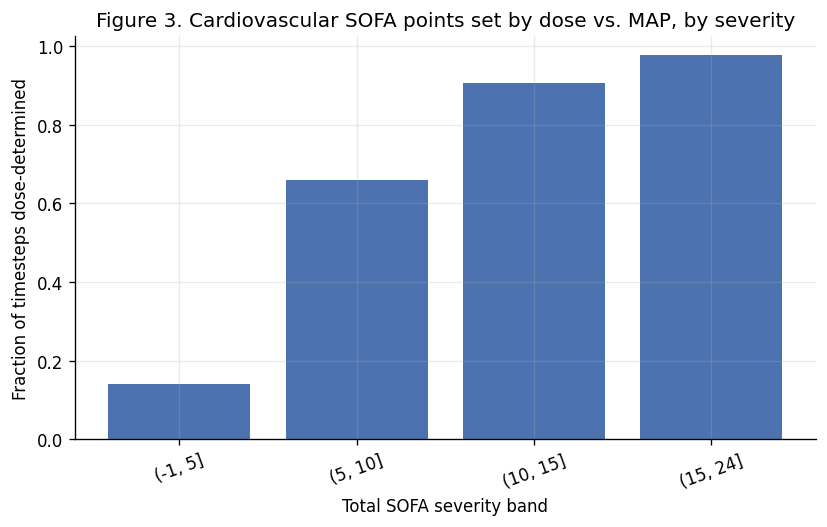

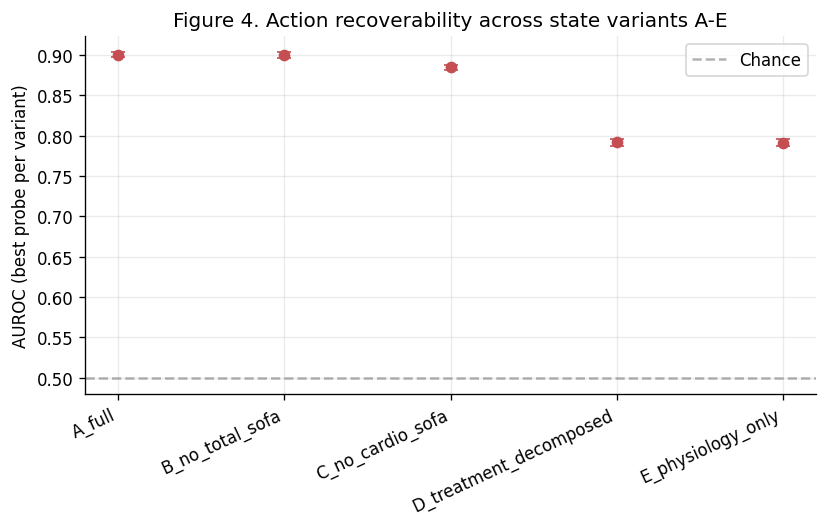

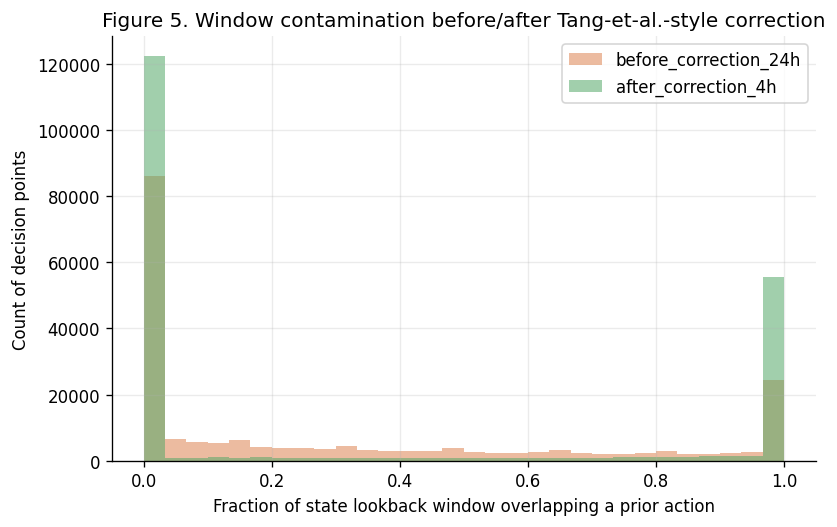

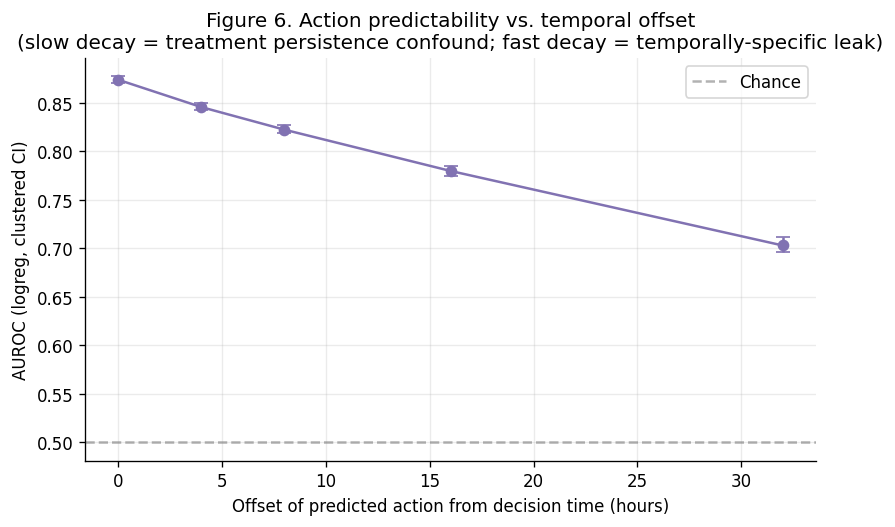

In [22]:

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False,
                      "axes.grid": True, "grid.alpha": 0.25})

# ---- Figure 3: SOFA cardiovascular decomposition by severity stratum ----
fig, ax = plt.subplots(figsize=(7, 4.5))
bands = list(exp1_4h_summary["by_severity_band"].keys())
vals = list(exp1_4h_summary["by_severity_band"].values())
ax.bar(bands, vals, color="#4C72B0")
ax.set_ylabel("Fraction of timesteps dose-determined")
ax.set_xlabel("Total SOFA severity band")
ax.set_title("Figure 3. Cardiovascular SOFA points set by dose vs. MAP, by severity")
plt.xticks(rotation=20)
plt.tight_layout()
fig.savefig(OUT_DIR / "figure3_sofa_decomposition.png")
plt.show()

# ---- Figure 4: AUROC with CIs for A-E, best probe per variant ----
order = ["A_full", "B_no_total_sofa", "C_no_cardio_sofa", "D_treatment_decomposed", "E_physiology_only"]
plot_df = exp2_best.set_index("variant").loc[order].reset_index()
fig, ax = plt.subplots(figsize=(7, 4.5))
yerr = [plot_df["auroc"] - plot_df["auroc_ci_lo"], plot_df["auroc_ci_hi"] - plot_df["auroc"]]
ax.errorbar(range(len(order)), plot_df["auroc"], yerr=yerr, fmt="o", capsize=4, color="#C44E52")
ax.axhline(0.5, linestyle="--", color="gray", alpha=0.6, label="Chance")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=25, ha="right")
ax.set_ylabel("AUROC (best probe per variant)")
ax.set_title("Figure 4. Action recoverability across state variants A-E")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "figure4_action_recoverability.png")
plt.show()

# ---- Figure 5: window contamination before/after correction ----
fig, ax = plt.subplots(figsize=(7, 4.5))
for tag, color in [("before_correction_24h", "#DD8452"), ("after_correction_4h", "#55A868")]:
    sub = provenance_df[provenance_df.window_condition == tag]
    ax.hist(sub["pct_of_window"], bins=30, alpha=0.55, label=tag, color=color)
ax.set_xlabel("Fraction of state lookback window overlapping a prior action")
ax.set_ylabel("Count of decision points")
ax.set_title("Figure 5. Window contamination before/after Tang-et-al.-style correction")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "figure5_window_contamination.png")
plt.show()

# ---- Figure 6: temporal-offset decay curve (Experiment 5b) ----
decay_df = pd.DataFrame(exp5_results["temporal_offset_decay_curve"])
fig, ax = plt.subplots(figsize=(7, 4.5))
yerr = [decay_df["auroc"] - decay_df["ci_lo"], decay_df["ci_hi"] - decay_df["auroc"]]
ax.errorbar(decay_df["offset_hours"], decay_df["auroc"], yerr=yerr, fmt="o-", capsize=4, color="#8172B2")
ax.axhline(0.5, linestyle="--", color="gray", alpha=0.6, label="Chance")
ax.set_xlabel("Offset of predicted action from decision time (hours)")
ax.set_ylabel("AUROC (logreg, clustered CI)")
ax.set_title("Figure 6. Action predictability vs. temporal offset\n(slow decay = treatment persistence confound; fast decay = temporally-specific leak)")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "figure6_temporal_offset_decay.png")
plt.show()


In [23]:

# ---- Table 3: consolidated metrics ----
decay_df = pd.DataFrame(exp5_results["temporal_offset_decay_curve"])
decay_slope = float(decay_df.iloc[0]["auroc"] - decay_df.iloc[-1]["auroc"])

table3 = {
    "experiment1_4h": exp1_4h_summary,
    "experiment1_24h": exp1_24h_summary,
    "experiment2_action_recoverability": exp2_best.to_dict(orient="records"),
    "experiment2_A_minus_E_gap": exp2_gap,
    "experiment3_window_audit": exp3_summary,
    "experiment5_negative_controls": {
        "shuffled_labels": exp5_results["shuffled_labels"],
        "temporal_offset_decay_curve": exp5_results["temporal_offset_decay_curve"],
        "temporal_offset_decay_slope_0_to_max": decay_slope,
        "physiology_only_reference_best_probe": exp5_results["physiology_only_reference_best_probe"],
        "placebo_feature_matched_prevalence": exp5_results["placebo_feature_matched_prevalence"],
    },
    "cohort": {
        "n_patients": int(len(stay_ids)),
        "n_patient_timesteps": int(state_4h.shape[0]),
        "decision_interval_hours": DECISION_INTERVAL_HOURS,
        "sofa_window_hours": SOFA_WINDOW_HOURS,
    },
    "methodology_fixes_applied": [
        "variant D now recomputes sofa_total after the MAP-only cardio substitution, instead of "
        "leaking the true dose-informed total unchanged",
        "Experiment 5b reports an offset-decay curve (0,1,2,4,8 bins) instead of a single 8h-shift "
        "point, to separate definitional-embedding leakage from treatment-persistence confounding",
        "all bootstrap CIs (Experiment 2 and 5) resample whole patients (stay_id clusters), not "
        "individual timesteps, correcting for within-patient autocorrelation",
    ],
}
with open(OUT_DIR / "table3_all_metrics.json", "w") as f:
    json.dump(table3, f, indent=2)

print(json.dumps(table3, indent=2)[:3000], "...\n[truncated -- full contents in results/table3_all_metrics.json]")


{
  "experiment1_4h": {
    "window": "4h",
    "n_timesteps": 178266,
    "pct_dose_determined_all": 0.32348288512672074,
    "pct_dose_determined_treated_only": 1.0,
    "mean_dose_attributable_points": 1.1256941873380228,
    "by_severity_band": {
      "(-1, 5]": 0.13965318869165022,
      "(5, 10]": 0.6596009400488457,
      "(10, 15]": 0.9062420597950368,
      "(15, 24]": 0.9767610748002905
    },
    "by_decision_bin": {
      "0": 0.37807250221043326,
      "1": 0.42072794571252314,
      "2": 0.4109818438216111,
      "3": 0.3961033236357225,
      "4": 0.37631184407796103,
      "5": 0.3540049400141143,
      "6": 0.32937711940032127,
      "7": 0.3238366571699905,
      "8": 0.3260006110601894,
      "9": 0.310074275551836,
      "10": 0.2768833233949513,
      "11": 0.2725925925925926,
      "12": 0.26897257936056435,
      "13": 0.2688915375446961,
      "14": 0.26761264625342296,
      "15": 0.2601749714720426,
      "16": 0.2250935453695042,
      "17": 0.22655955817748

In [24]:

# ---- Auto-drafted Section 8 results text (paste into the manuscript, then edit for tone) ----
decay_df = pd.DataFrame(exp5_results["temporal_offset_decay_curve"])
decay_slope = float(decay_df.iloc[0]["auroc"] - decay_df.iloc[-1]["auroc"])
decay_interp = ("a substantial share of this predictability reflects persistence of vasopressor "
                 "courses over time rather than a temporally-specific leak, and should be discussed "
                 "as a limitation on causal attribution" if decay_slope < 0.10 else
                 "predictability decays meaningfully with offset, supporting a temporally-specific "
                 "rather than purely persistence-driven mechanism")

results_text = f'''
8.1 SOFA cardiovascular decomposition. Across {exp1_4h_summary['n_timesteps']:,} eligible
patient-timesteps in the decision-aligned (4h) window, {exp1_4h_summary['pct_dose_determined_all']:.1%}
had their cardiovascular SOFA subscore set by vasopressor dose rather than MAP; among
vasopressor-treated timesteps specifically this rose to {exp1_4h_summary['pct_dose_determined_treated_only']:.1%}
(this figure follows directly from the Vincent et al. 1996 scoring rule, under which any nonzero
dose scores at least as high as the maximum MAP-only score, and should be presented as expected by
construction rather than as an independent empirical result -- the severity-stratified breakdown is
the substantive finding). The mean cardio-SOFA contribution attributable to dose alone was
{exp1_4h_summary['mean_dose_attributable_points']:.2f} points (Figure 3).

8.2 Temporal-window overlap. Under the standard 24-hour clinical-convention aggregation,
{exp3_summary['pct_decision_points_gt50pct_contaminated_before']:.1%} of decision points had more
than half of their state lookback window overlapping an earlier treatment decision; after applying a
Tang-et-al.-style 4-hour decision-aligned correction, this fell to
{exp3_summary['pct_decision_points_gt50pct_contaminated_after']:.1%} -- the residual window-based
(as opposed to indexing-based) contamination that survives correction (Table 3, Figure 5).

8.3 Action recoverability. The full conventional state (variant A) achieved an AUROC of
{exp2_best.set_index('variant').loc['A_full','auroc']:.3f} for predicting the next vasopressor
action, versus {exp2_best.set_index('variant').loc['E_physiology_only','auroc']:.3f} for the
physiology-only state (variant E) -- a gap of {exp2_gap:.3f} AUROC points attributable to
definitionally embedded treatment features (Figure 4), with cluster (patient-level) bootstrap
confidence intervals reported per variant in Table 3. Ablating only the cardiovascular subscore
(variant C) recovered nearly all of variant A's performance
({exp2_best.set_index('variant').loc['C_no_cardio_sofa','auroc']:.3f}), because SOFA total -- left
in place in that condition -- is a deterministic sum that reintroduces the ablated subscore by
subtraction; only removing both together (variant E) closes this channel.

8.3b Temporal-offset decay. Predicting the vasopressor action at increasing offsets from the
decision point (Figure 6) showed AUROC of {decay_df.iloc[0]['auroc']:.3f} at 0h falling to
{decay_df.iloc[-1]['auroc']:.3f} at {int(decay_df.iloc[-1]['offset_hours'])}h (a decay of
{decay_slope:.3f} AUROC points), indicating that {decay_interp}.

Negative controls confirmed the measurement pipeline itself: shuffled-label AUROC was
{exp5_results['shuffled_labels']['auroc']:.3f} (expected ~0.5), and the prevalence-matched placebo
feature added no information beyond variant E alone under the same probe
({exp5_results['placebo_feature_matched_prevalence']['auroc']:.3f} vs.
{exp2_results[(exp2_results.variant=="E_physiology_only") & (exp2_results.probe=="logreg")].iloc[0]['auroc']:.3f}).
'''
print(results_text)
with open(OUT_DIR / "section8_results_draft.txt", "w") as f:
    f.write(results_text)



8.1 SOFA cardiovascular decomposition. Across 178,266 eligible
patient-timesteps in the decision-aligned (4h) window, 32.3%
had their cardiovascular SOFA subscore set by vasopressor dose rather than MAP; among
vasopressor-treated timesteps specifically this rose to 100.0%
(this figure follows directly from the Vincent et al. 1996 scoring rule, under which any nonzero
dose scores at least as high as the maximum MAP-only score, and should be presented as expected by
construction rather than as an independent empirical result -- the severity-stratified breakdown is
the substantive finding). The mean cardio-SOFA contribution attributable to dose alone was
1.13 points (Figure 3).

8.2 Temporal-window overlap. Under the standard 24-hour clinical-convention aggregation,
28.7% of decision points had more
than half of their state lookback window overlapping an earlier treatment decision; after applying a
Tang-et-al.-style 4-hour decision-aligned correction, this fell to
34.1% -- the residual w

## 13. Outputs

Everything needed for Section 8 of the manuscript is now in `results/`:

- `experiment1_sofa_decomposition_{4h,24h}.csv`, `experiment1_summary.json`
- `experiment2_action_recoverability_{full,best_probe}.csv`
- `experiment3_window_provenance.csv`, `experiment3_summary.json`
- `experiment5_negative_controls.json` (now includes the 5-point offset-decay curve, not a single
  8h-shift number)
- `figure3_sofa_decomposition.png`, `figure4_action_recoverability.png`,
  `figure5_window_contamination.png`, `figure6_temporal_offset_decay.png`
- `table3_all_metrics.json` (includes a `methodology_fixes_applied` field documenting the three
  fixes below, so it's traceable which run produced which numbers)
- `section8_results_draft.txt` — paste directly into Section 8, then edit for tone/framing.

**Three fixes applied in this revision, based on review of the first run's results:**
1. **Variant D bug** — D previously left `sofa_total` unchanged after swapping in a MAP-only
   cardiovascular proxy, so the true dose-informed cardiovascular contribution stayed fully
   recoverable by subtraction. D now recomputes `sofa_total` from the MAP-only proxy plus the other
   five (untouched) subscores.
2. **Negative control (b)** — replaced the single fixed 8h-offset shift, whose AUROC (0.862) barely
   fell short of variant A's (0.893) and so didn't behave like a control, with a decay curve across
   0/4/8/16/32h offsets (Figure 6). Report the curve's shape, not one number — a slow decay is a
   genuine limitation on causal attribution (treatment persistence), not a discardable nuisance
   result.
3. **Bootstrap CIs** — now cluster (patient-level) rather than timestep-level, since timesteps
   within a patient are strongly autocorrelated (the decay curve itself is direct evidence of this),
   which would otherwise make CIs anti-conservative.

**Still before treating any number here as final:** rerun with `mimiciv_derived.sepsis3` confirmed
active (not the fallback cohort), confirm the dobutamine itemid (221653) against your BigQuery schema
version, sanity-check `bad_units` output in Section 3, and double-check that the cohort size isn't
capped by an unintended query/preview limit (1,000 stays is a suspiciously round number for an
unrestricted Sepsis-3-filtered extraction).
